# Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = "data/SMS International.csv"

df = pd.read_csv(csv_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94335 entries, 0 to 94334
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      94335 non-null  int64  
 1   Month                     94335 non-null  int64  
 2   Client                    94335 non-null  str    
 3   ClientConnection          94335 non-null  str    
 4   Supplier                  94335 non-null  str    
 5   SupplierConnection        94335 non-null  str    
 6   SupplierConnectionLink    94201 non-null  str    
 7   Route                     94335 non-null  str    
 8   Country                   94335 non-null  str    
 9   Network                   94335 non-null  str    
 10  OAProfiledCategory        93215 non-null  str    
 11  CostCurrency              94335 non-null  str    
 12  PriceCurrency             94335 non-null  str    
 13  ProfitCurrency            94335 non-null  str    
 14  BaseCurrency     

/var/folders/3g/qnv3tv0j2xj4fh2gvhwzdblc0000gn/T/ipykernel_186/1741452482.py:8: DtypeWarning: Columns (0: TotalRevenue, 1: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


## Data Cleaning

In [2]:
# Normalisasi nilai kategorikal sebelum masking
if 'Network' not in df.columns:
    raise ValueError("Kolom 'Network' tidak ditemukan di dataframe.")

# Simpan snapshot sebelum cleaning untuk verifikasi
network_before = df['Network'].astype(str).value_counts(dropna=False)

# Rapikan spasi dan normalisasi typo umum
df['Network'] = df['Network'].astype(str).str.strip()
df['Network'] = df['Network'].replace({
    r'(?i)^telkomcel$': 'Telkomsel',
    r'(?i)^telkomsel$': 'Telkomsel'
}, regex=True)

network_after = df['Network'].astype(str).value_counts(dropna=False)

print("=== Sebelum cleaning (Network) ===")
print(network_before.loc[[idx for idx in network_before.index if 'telkom' in str(idx).lower()]] if any('telkom' in str(idx).lower() for idx in network_before.index) else 'Tidak ada nilai Telkom* sebelum cleaning')

print("\n=== Sesudah cleaning (Network) ===")
print(network_after.loc[[idx for idx in network_after.index if 'telkom' in str(idx).lower()]] if any('telkom' in str(idx).lower() for idx in network_after.index) else 'Tidak ada nilai Telkom* sesudah cleaning')

=== Sebelum cleaning (Network) ===
Network
Telkomsel    78991
Telkomcel       27
Name: count, dtype: int64

=== Sesudah cleaning (Network) ===
Network
Telkomsel    79018
Name: count, dtype: int64


# Data Masking (Anonymization)
Masking otomatis kolom sensitif agar nama perusahaan/provider/supplier/partner/network tidak terekspos pada analisis dan visualisasi.

In [3]:
# Identifikasi kolom sensitif berdasarkan nama kolom (case-insensitive)
sensitive_keywords = [
    "client", "company", "provider", "supplier",
    "partner", "network", "route", "connection", "oaprofiledcategory"
]

sensitive_columns = [
    col for col in df.columns
    if any(keyword in col.lower() for keyword in sensitive_keywords)
]

def mask_column(series, label):
    """Masking deterministik: nilai unik -> token anonim per kolom."""
    clean_values = sorted(series.dropna().astype(str).unique())
    mapping = {value: f"{label}_{idx:03d}" for idx, value in enumerate(clean_values, start=1)}

    masked = series.astype(str).map(mapping)
    masked = masked.where(series.notna(), np.nan)
    return masked, mapping

masking_maps = {}

for col in sensitive_columns:
    masked_series, mapping = mask_column(df[col], col.upper())
    df[col] = masked_series
    masking_maps[col] = mapping

print("Kolom yang dimasking:", sensitive_columns)
print("Contoh data setelah masking:")
display(df.head(3))

Kolom yang dimasking: ['Client', 'ClientConnection', 'Supplier', 'SupplierConnection', 'SupplierConnectionLink', 'Route', 'Network', 'OAProfiledCategory']
Contoh data setelah masking:


,Year,Month,Client,ClientConnection,Supplier,SupplierConnection,SupplierConnectionLink,Route,Country,Network,...,ProfitCurrency,BaseCurrency,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages,Unnamed: 21,Unnamed: 22
0,2023,2,CLIENT_031,CLIENTCONNECTION_065,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_005,ROUTE_041,Indonesia,NETWORK_007,...,USD,USD,156263,1401484,1245221,9766437,9079388,157978,NaN,NaN
1,2023,5,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_005,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,24049,1239724,1215675,5959192,5390105,569087,NaN,NaN
2,2023,5,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,24510,1236721,1212211,5942211,5377049,565162,NaN,NaN


In [4]:
# WIth analyze in original data the OA Profiled Category has same name with SupplierConnection name or it's not exactly same but it has same meaning.
df['OAProfiledCategory'].head()

0    OAPROFILEDCATEGORY_1391
1    OAPROFILEDCATEGORY_1391
2    OAPROFILEDCATEGORY_1391
3    OAPROFILEDCATEGORY_1391
4    OAPROFILEDCATEGORY_1391
Name: OAProfiledCategory, dtype: str

In [5]:
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'], errors='ignore')

In [6]:
# df = df.drop(columns=['TotalProfit'], errors='ignore')

In [7]:
df.to_csv("data/SMS_International_masked.csv", index=False)

In [8]:
df['Country'].value_counts()

Country
Indonesia                   79039
Sri Lanka                   15254
East Timor                     27
United States of America       13
Portugal                        2
Name: count, dtype: int64

In [9]:
df

,Year,Month,Client,ClientConnection,Supplier,SupplierConnection,SupplierConnectionLink,Route,Country,Network,...,CostCurrency,PriceCurrency,ProfitCurrency,BaseCurrency,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
0,2023,2,CLIENT_031,CLIENTCONNECTION_065,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_005,ROUTE_041,Indonesia,NETWORK_007,...,USD,USD,USD,USD,156263,1401484,1245221,9766437,9079388,157978
1,2023,5,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_005,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,USD,USD,24049,1239724,1215675,5959192,5390105,569087
2,2023,5,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,USD,USD,24510,1236721,1212211,5942211,5377049,565162
3,2023,6,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,USD,USD,-22762,1193231,1215993,5960748,5187960,772788
4,2023,6,CLIENT_017,CLIENTCONNECTION_001,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_005,ROUTE_020,Indonesia,NETWORK_007,...,USD,USD,USD,USD,-22585,1192948,1215533,5958494,5186730,771764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94330,2024,2,CLIENT_022,CLIENTCONNECTION_092,SUPPLIER_001,SUPPLIERCONNECTION_002,SUPPLIERCONNECTIONLINK_004,ROUTE_075,Indonesia,NETWORK_009,...,-,IDR,USD,USD,-,-,-,1,-,-
94331,2024,5,CLIENT_022,CLIENTCONNECTION_092,SUPPLIER_001,SUPPLIERCONNECTION_002,SUPPLIERCONNECTIONLINK_004,ROUTE_075,Indonesia,NETWORK_009,...,-,IDR,USD,USD,-,-,-,1,-,-
94332,2024,8,CLIENT_022,CLIENTCONNECTION_092,SUPPLIER_001,SUPPLIERCONNECTION_002,SUPPLIERCONNECTIONLINK_004,ROUTE_075,Indonesia,NETWORK_009,...,-,IDR,USD,USD,-,-,-,2,-,-
94333,2024,10,CLIENT_022,CLIENTCONNECTION_092,SUPPLIER_001,SUPPLIERCONNECTION_002,SUPPLIERCONNECTIONLINK_004,ROUTE_075,Indonesia,NETWORK_009,...,-,IDR,USD,USD,-,-,-,1,-,-


In [10]:
df['Client'].value_counts()

Client
CLIENT_031    50915
CLIENT_027     6725
CLIENT_041     5579
CLIENT_032     3762
CLIENT_044     3515
CLIENT_047     2714
CLIENT_024     2569
CLIENT_038     2438
CLIENT_028     2124
CLIENT_037     2037
CLIENT_021     1550
CLIENT_042     1191
CLIENT_050     1167
CLIENT_007      971
CLIENT_025      916
CLIENT_030      862
CLIENT_022      655
CLIENT_016      650
CLIENT_054      599
CLIENT_011      338
CLIENT_015      314
CLIENT_002      264
CLIENT_045      248
CLIENT_008      239
CLIENT_013      236
CLIENT_036      217
CLIENT_040      206
CLIENT_012      202
CLIENT_018      199
CLIENT_014      173
CLIENT_017      134
CLIENT_051      116
CLIENT_005       74
CLIENT_023       61
CLIENT_020       59
CLIENT_003       54
CLIENT_001       50
CLIENT_010       44
CLIENT_034       33
CLIENT_053       25
CLIENT_043       20
CLIENT_029       12
CLIENT_052       11
CLIENT_046       10
CLIENT_009        9
CLIENT_049        9
CLIENT_019        8
CLIENT_035        7
CLIENT_004        7
CLIENT_048   

In [11]:
df['CostCurrency'].value_counts()

CostCurrency
USD    94015
-        320
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94335 entries, 0 to 94334
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      94335 non-null  int64 
 1   Month                     94335 non-null  int64 
 2   Client                    94335 non-null  str   
 3   ClientConnection          94335 non-null  str   
 4   Supplier                  94335 non-null  str   
 5   SupplierConnection        94335 non-null  str   
 6   SupplierConnectionLink    94201 non-null  str   
 7   Route                     94335 non-null  str   
 8   Country                   94335 non-null  str   
 9   Network                   94335 non-null  str   
 10  OAProfiledCategory        93215 non-null  str   
 11  CostCurrency              94335 non-null  str   
 12  PriceCurrency             94335 non-null  str   
 13  ProfitCurrency            94335 non-null  str   
 14  BaseCurrency              94335 n

In [13]:
df_terurut = df.sort_values(by=['Year', 'Month'], ascending=True)
print(df_terurut.head())

    Year  Month      Client      ClientConnection      Supplier  \
5   2023      1  CLIENT_030  CLIENTCONNECTION_071  SUPPLIER_001   
34  2023      1  CLIENT_013  CLIENTCONNECTION_028  SUPPLIER_001   
35  2023      1  CLIENT_013  CLIENTCONNECTION_028  SUPPLIER_001   
43  2023      1  CLIENT_013  CLIENTCONNECTION_028  SUPPLIER_001   
44  2023      1  CLIENT_013  CLIENTCONNECTION_028  SUPPLIER_001   

        SupplierConnection      SupplierConnectionLink      Route    Country  \
5   SUPPLIERCONNECTION_001  SUPPLIERCONNECTIONLINK_001  ROUTE_037  Indonesia   
34  SUPPLIERCONNECTION_004  SUPPLIERCONNECTIONLINK_002  ROUTE_016  Indonesia   
35  SUPPLIERCONNECTION_004  SUPPLIERCONNECTIONLINK_006  ROUTE_016  Indonesia   
43  SUPPLIERCONNECTION_004  SUPPLIERCONNECTIONLINK_006  ROUTE_016  Indonesia   
44  SUPPLIERCONNECTION_004  SUPPLIERCONNECTIONLINK_002  ROUTE_016  Indonesia   

        Network  ... CostCurrency PriceCurrency ProfitCurrency BaseCurrency  \
5   NETWORK_007  ...          USD    

In [14]:
df_terurut.head()

,Year,Month,Client,ClientConnection,Supplier,SupplierConnection,SupplierConnectionLink,Route,Country,Network,...,CostCurrency,PriceCurrency,ProfitCurrency,BaseCurrency,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,...,USD,USD,USD,USD,12774,1098604,1085830,8516311,7900562,143330
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,124438,810829,686391,7925994,6549499,819832
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,124430,810779,686348,7925501,6548783,820443
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,115604,753265,637661,7363296,6180515,867061
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,115508,752645,637136,7357229,6174895,866668


In [15]:
df_terurut

,Year,Month,Client,ClientConnection,Supplier,SupplierConnection,SupplierConnectionLink,Route,Country,Network,...,CostCurrency,PriceCurrency,ProfitCurrency,BaseCurrency,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIER_001,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,...,USD,USD,USD,USD,12774,1098604,1085830,8516311,7900562,143330
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,124438,810829,686391,7925994,6549499,819832
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,124430,810779,686348,7925501,6548783,820443
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,115604,753265,637661,7363296,6180515,867061
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIER_001,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,...,USD,USD,USD,USD,115508,752645,637136,7357229,6174895,866668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94307,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIER_001,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,...,USD,USD,USD,USD,0,-,0,3,-,-
94308,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIER_001,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,...,USD,USD,USD,USD,0,-,0,1,-,-
94309,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIER_001,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,...,USD,USD,USD,USD,0,-,0,6,-,6
94310,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIER_001,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,...,USD,USD,USD,USD,0,-,0,3,-,3


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94335 entries, 0 to 94334
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      94335 non-null  int64 
 1   Month                     94335 non-null  int64 
 2   Client                    94335 non-null  str   
 3   ClientConnection          94335 non-null  str   
 4   Supplier                  94335 non-null  str   
 5   SupplierConnection        94335 non-null  str   
 6   SupplierConnectionLink    94201 non-null  str   
 7   Route                     94335 non-null  str   
 8   Country                   94335 non-null  str   
 9   Network                   94335 non-null  str   
 10  OAProfiledCategory        93215 non-null  str   
 11  CostCurrency              94335 non-null  str   
 12  PriceCurrency             94335 non-null  str   
 13  ProfitCurrency            94335 non-null  str   
 14  BaseCurrency              94335 n

In [17]:
df_terurut = df_terurut.drop(['PriceCurrency', 'ProfitCurrency', 'BaseCurrency', 'CostCurrency', 'Supplier'], axis=1)

In [18]:
df_terurut

,Year,Month,Client,ClientConnection,SupplierConnection,SupplierConnectionLink,Route,Country,Network,OAProfiledCategory,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1391,12774,1098604,1085830,8516311,7900562,143330
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124438,810829,686391,7925994,6549499,819832
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124430,810779,686348,7925501,6548783,820443
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115604,753265,637661,7363296,6180515,867061
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115508,752645,637136,7357229,6174895,866668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94307,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2579,0,-,0,3,-,-
94308,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2608,0,-,0,1,-,-
94309,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2590,0,-,0,6,-,6
94310,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2565,0,-,0,3,-,3


In [19]:
df_terurut.info()

<class 'pandas.DataFrame'>
Index: 94335 entries, 5 to 94311
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      94335 non-null  int64 
 1   Month                     94335 non-null  int64 
 2   Client                    94335 non-null  str   
 3   ClientConnection          94335 non-null  str   
 4   SupplierConnection        94335 non-null  str   
 5   SupplierConnectionLink    94201 non-null  str   
 6   Route                     94335 non-null  str   
 7   Country                   94335 non-null  str   
 8   Network                   94335 non-null  str   
 9   OAProfiledCategory        93215 non-null  str   
 10  TotalProfit               94335 non-null  str   
 11  TotalRevenue              94335 non-null  object
 12  TotalCost                 94335 non-null  str   
 13  TotalSentMessages         94335 non-null  int64 
 14  TotalDeliveredMessages    94335 non-nu

In [20]:
df_terurut

,Year,Month,Client,ClientConnection,SupplierConnection,SupplierConnectionLink,Route,Country,Network,OAProfiledCategory,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1391,12774,1098604,1085830,8516311,7900562,143330
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124438,810829,686391,7925994,6549499,819832
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124430,810779,686348,7925501,6548783,820443
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115604,753265,637661,7363296,6180515,867061
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115508,752645,637136,7357229,6174895,866668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94307,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2579,0,-,0,3,-,-
94308,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2608,0,-,0,1,-,-
94309,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2590,0,-,0,6,-,6
94310,2024,12,CLIENT_038,CLIENTCONNECTION_084,SUPPLIERCONNECTION_003,SUPPLIERCONNECTIONLINK_003,ROUTE_056,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2565,0,-,0,3,-,3


In [21]:
df_terurut.info()

<class 'pandas.DataFrame'>
Index: 94335 entries, 5 to 94311
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      94335 non-null  int64 
 1   Month                     94335 non-null  int64 
 2   Client                    94335 non-null  str   
 3   ClientConnection          94335 non-null  str   
 4   SupplierConnection        94335 non-null  str   
 5   SupplierConnectionLink    94201 non-null  str   
 6   Route                     94335 non-null  str   
 7   Country                   94335 non-null  str   
 8   Network                   94335 non-null  str   
 9   OAProfiledCategory        93215 non-null  str   
 10  TotalProfit               94335 non-null  str   
 11  TotalRevenue              94335 non-null  object
 12  TotalCost                 94335 non-null  str   
 13  TotalSentMessages         94335 non-null  int64 
 14  TotalDeliveredMessages    94335 non-nu

In [22]:
df_terurut.head()

,Year,Month,Client,ClientConnection,SupplierConnection,SupplierConnectionLink,Route,Country,Network,OAProfiledCategory,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1391,12774,1098604,1085830,8516311,7900562,143330
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124438,810829,686391,7925994,6549499,819832
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124430,810779,686348,7925501,6548783,820443
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115604,753265,637661,7363296,6180515,867061
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115508,752645,637136,7357229,6174895,866668


In [23]:
df_terurut['Network'].unique()

<StringArray>
['NETWORK_007', 'NETWORK_001', 'NETWORK_009', 'NETWORK_003', 'NETWORK_002',
 'NETWORK_005', 'NETWORK_006', 'NETWORK_008', 'NETWORK_004']
Length: 9, dtype: str

# EDA - Analisis Pola Temporal
Analisis tren bulanan untuk melihat dinamika volume trafik, revenue, cost, dan perubahan month-to-month.

Ringkasan temporal (5 baris pertama):


,Year,Month,TotalRevenue,TotalCost,TotalSentMessages,TotalRevenue_MoM_pct,TotalCost_MoM_pct,TotalSentMessages_MoM_pct
0,2023,1,10246058.0,9071929.0,88626458,NaN,NaN,NaN
1,2023,2,9479717.0,8203344.0,80051114,-7.479374,-9.574425,-9.675828
2,2023,3,12374670.0,11182492.0,90329567,30.538391,36.316263,12.839863
3,2023,4,12887031.0,11767481.0,88149300,4.140401,5.231294,-2.413680
4,2023,5,12914688.0,11701207.0,87017869,0.214611,-0.563196,-1.283539


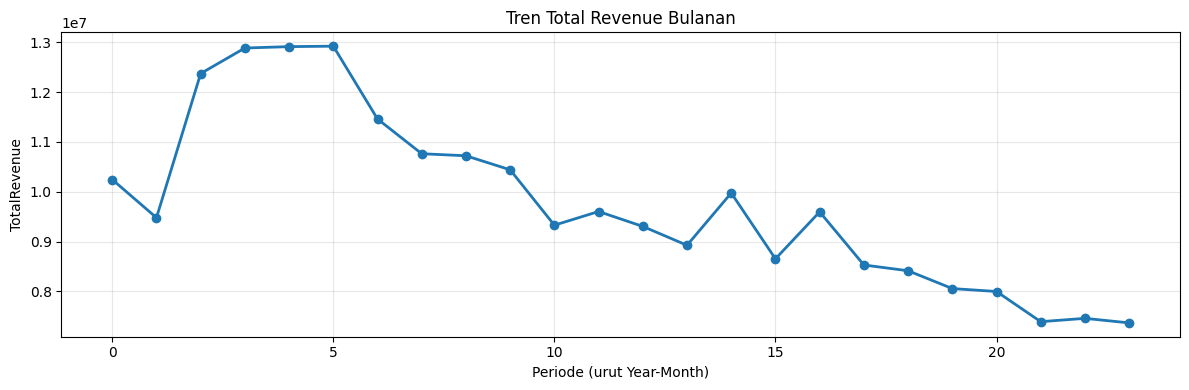

Disimpan: tren_revenue.png


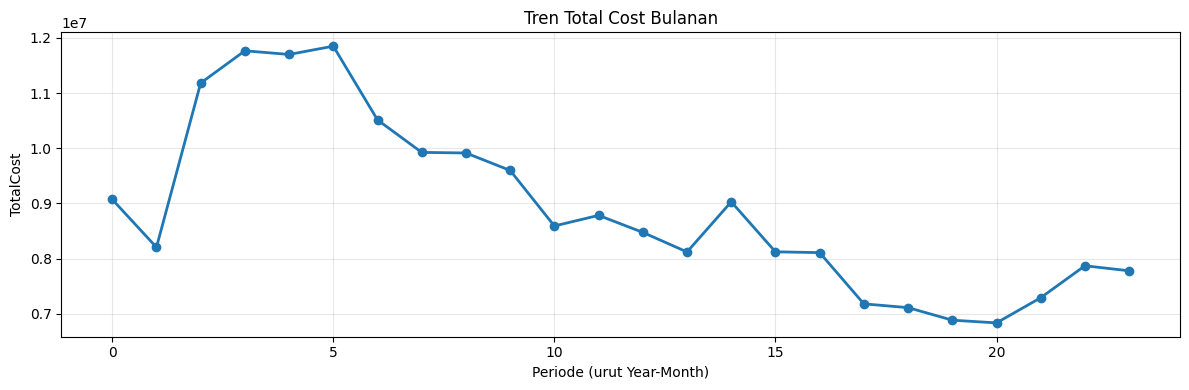

Disimpan: tren_cost.png


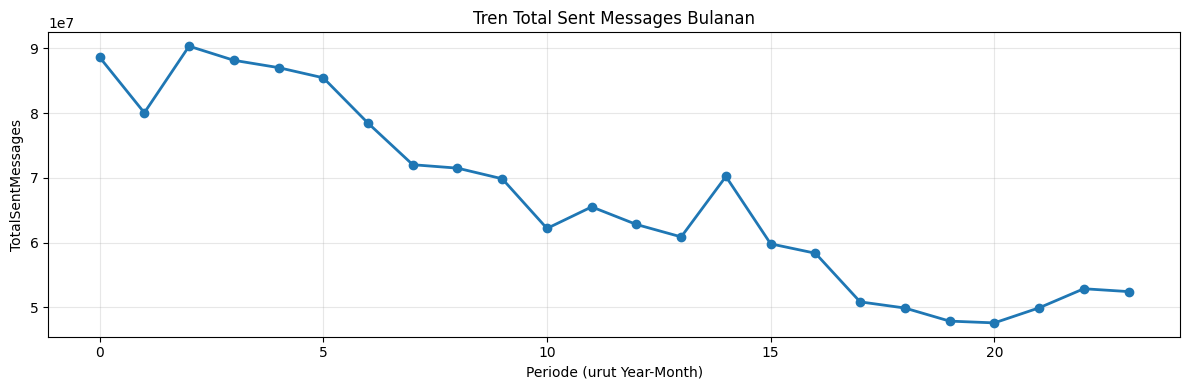

Disimpan: tren_sent_messages.png


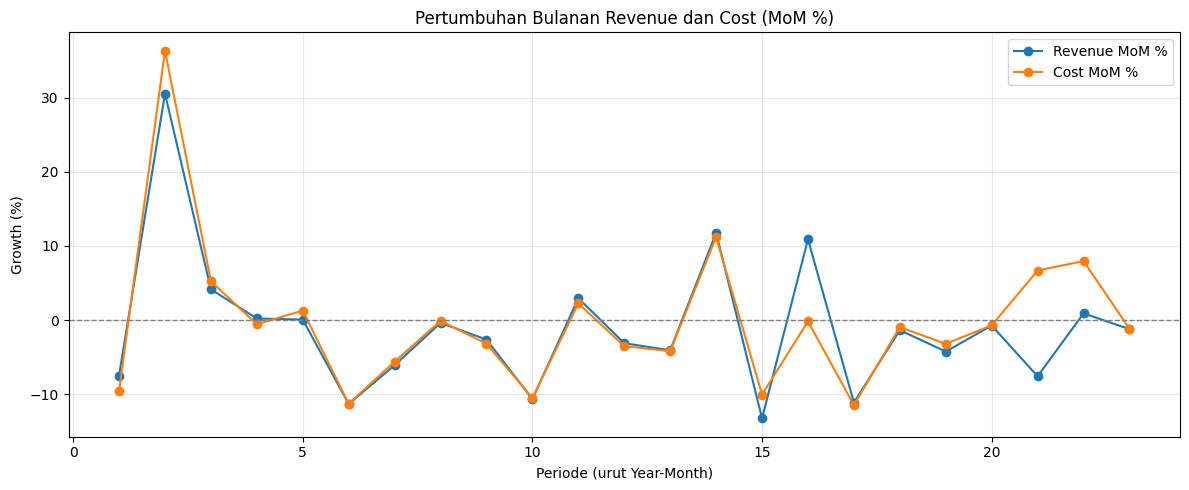

Disimpan: tren_mom_growth.png


In [24]:
# Pastikan kolom numerik temporal siap dihitung
temporal_cols = ['TotalRevenue', 'TotalCost', 'TotalSentMessages']
for col in temporal_cols:
    df_terurut[col] = pd.to_numeric(
        df_terurut[col].astype(str).str.replace(',', '', regex=False).str.replace(' ', '', regex=False),
        errors='coerce'
    )

# Agregasi bulanan
temporal_summary = (
    df_terurut
    .groupby(['Year', 'Month'], as_index=False)[temporal_cols]
    .sum()
    .sort_values(['Year', 'Month'])
    .reset_index(drop=True)
)

# Hitung pertumbuhan month-to-month (%)
for col in temporal_cols:
    temporal_summary[f'{col}_MoM_pct'] = temporal_summary[col].pct_change() * 100

print('Ringkasan temporal (5 baris pertama):')
display(temporal_summary.head())

# ── Tren individual — masing-masing figure terpisah ──────────────────
plot_configs = [
    ('TotalRevenue',      'Tren Total Revenue Bulanan',       'tren_revenue.png'),
    ('TotalCost',         'Tren Total Cost Bulanan',          'tren_cost.png'),
    ('TotalSentMessages', 'Tren Total Sent Messages Bulanan', 'tren_sent_messages.png'),
]

for col, title, fname in plot_configs:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(temporal_summary.index, temporal_summary[col], marker='o', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xlabel('Periode (urut Year-Month)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Disimpan: {fname}')

# ── Pertumbuhan MoM Revenue vs Cost ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(temporal_summary.index, temporal_summary['TotalRevenue_MoM_pct'], marker='o', label='Revenue MoM %')
ax.plot(temporal_summary.index, temporal_summary['TotalCost_MoM_pct'],    marker='o', label='Cost MoM %')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_title('Pertumbuhan Bulanan Revenue dan Cost (MoM %)')
ax.set_xlabel('Periode (urut Year-Month)')
ax.set_ylabel('Growth (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tren_mom_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Disimpan: tren_mom_growth.png')

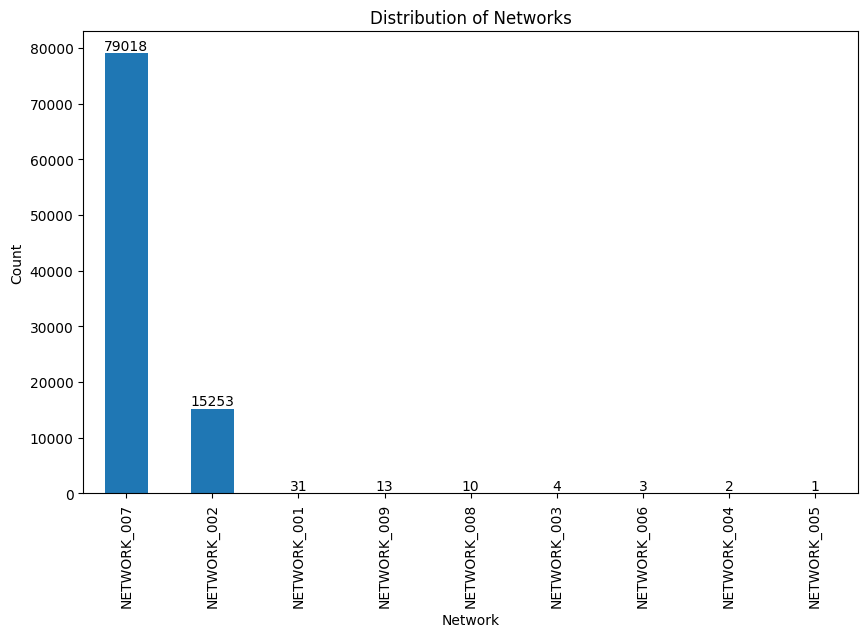

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df_terurut['Network'].value_counts().plot(kind='bar')
plt.title('Distribution of Networks')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Network')
plt.ylabel('Count')
plt.show()

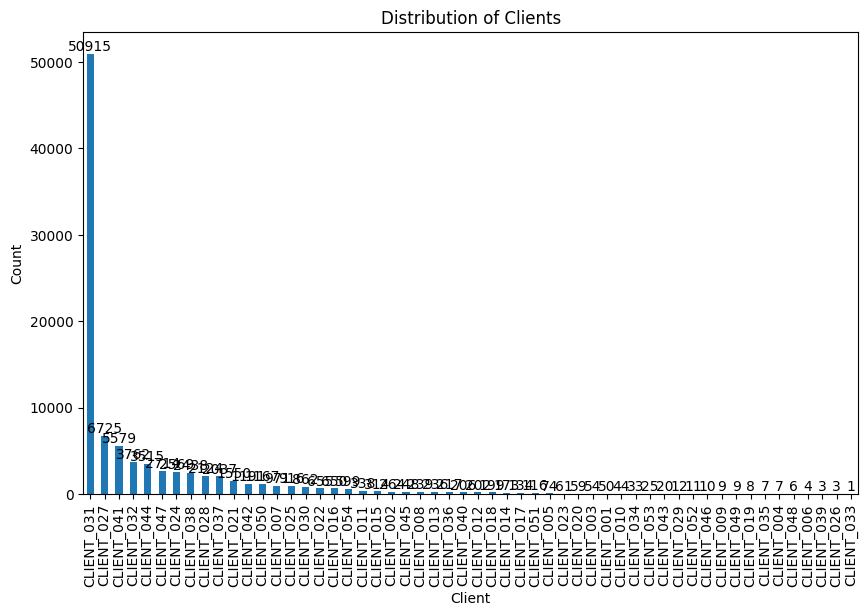

In [26]:
plt.figure(figsize=(10,6))
df['Client'].value_counts().plot(kind='bar')
plt.title('Distribution of Clients')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Client')
plt.ylabel('Count')
plt.show()

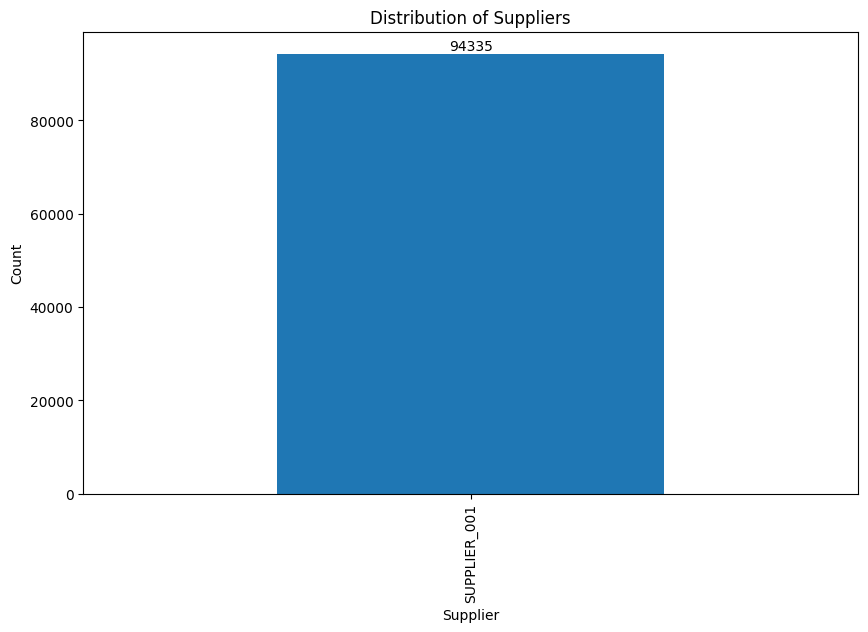

In [27]:
plt.figure(figsize=(10,6))
df['Supplier'].value_counts().plot(kind='bar')
plt.title('Distribution of Suppliers')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Supplier')
plt.ylabel('Count')
plt.show()

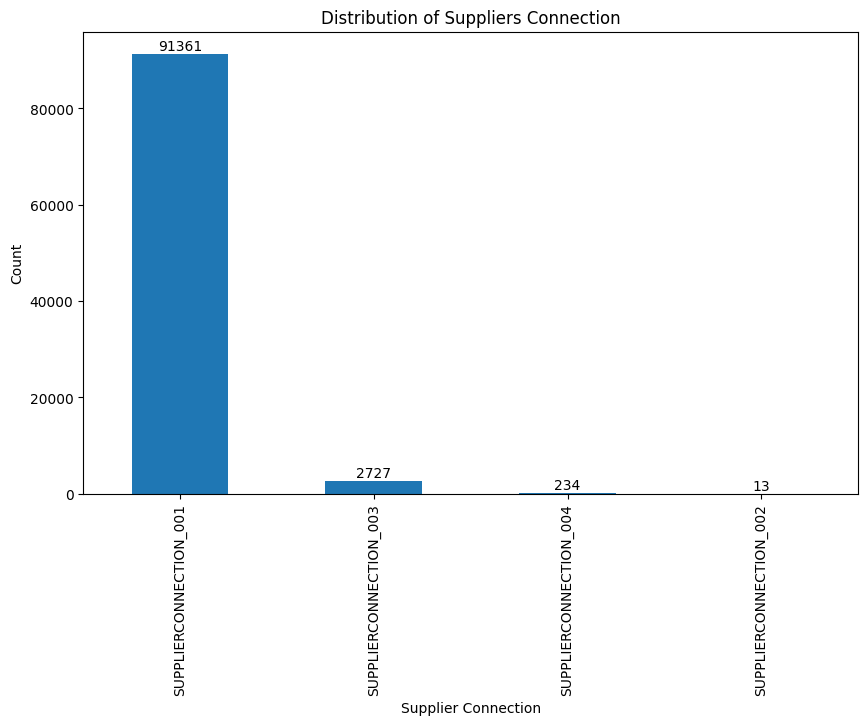

In [28]:
plt.figure(figsize=(10,6))
df['SupplierConnection'].value_counts().plot(kind='bar')
plt.title('Distribution of Suppliers Connection')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Supplier Connection')
plt.ylabel('Count')
plt.show()

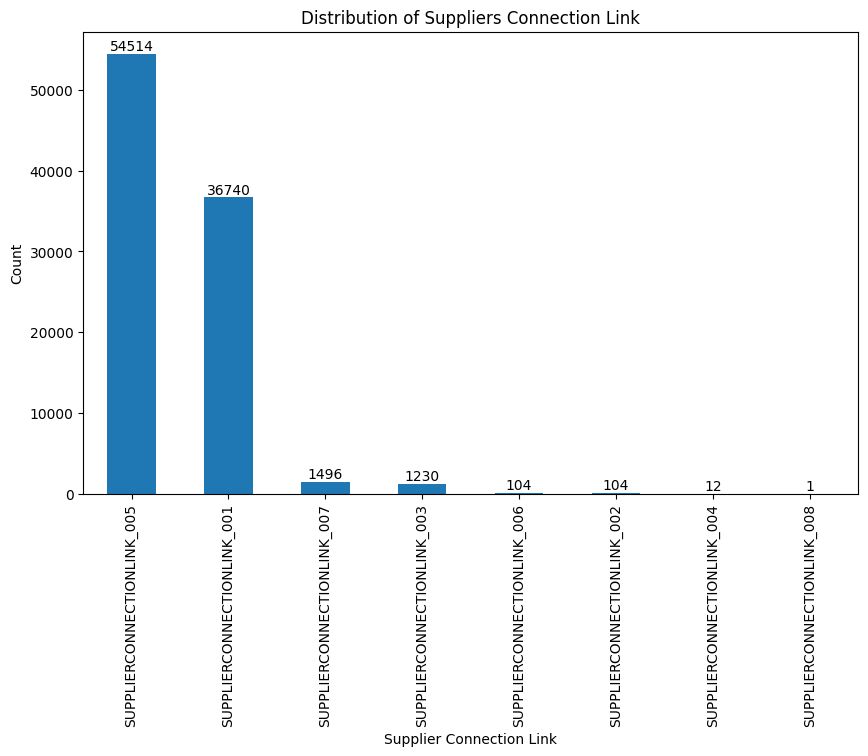

In [29]:
plt.figure(figsize=(10,6))
df['SupplierConnectionLink'].value_counts().plot(kind='bar')
plt.title('Distribution of Suppliers Connection Link')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Supplier Connection Link')
plt.ylabel('Count')
plt.show()

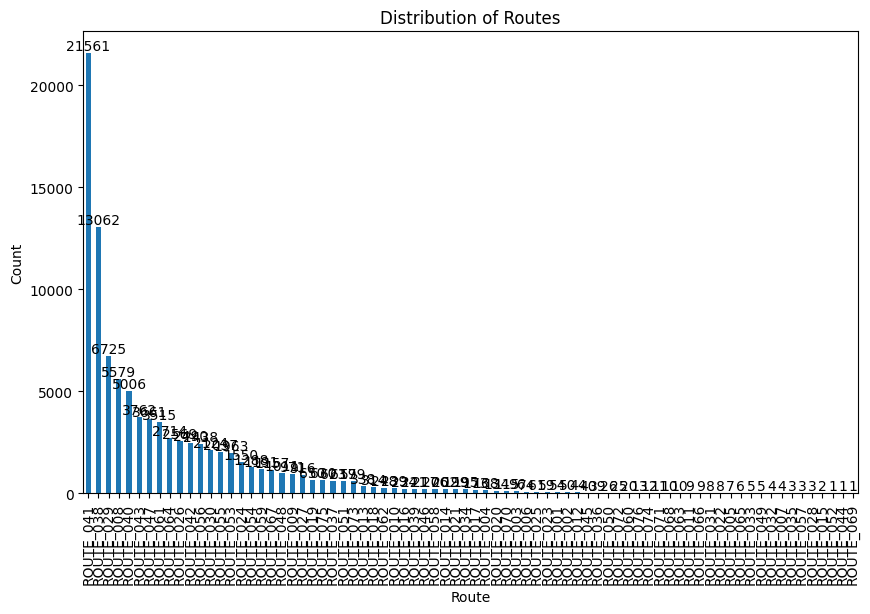

In [30]:
plt.figure(figsize=(10,6))
df['Route'].value_counts().plot(kind='bar')
plt.title('Distribution of Routes')
plt.bar_label(plt.gca().containers[0])
plt.xlabel('Route')
plt.ylabel('Count')
plt.show()

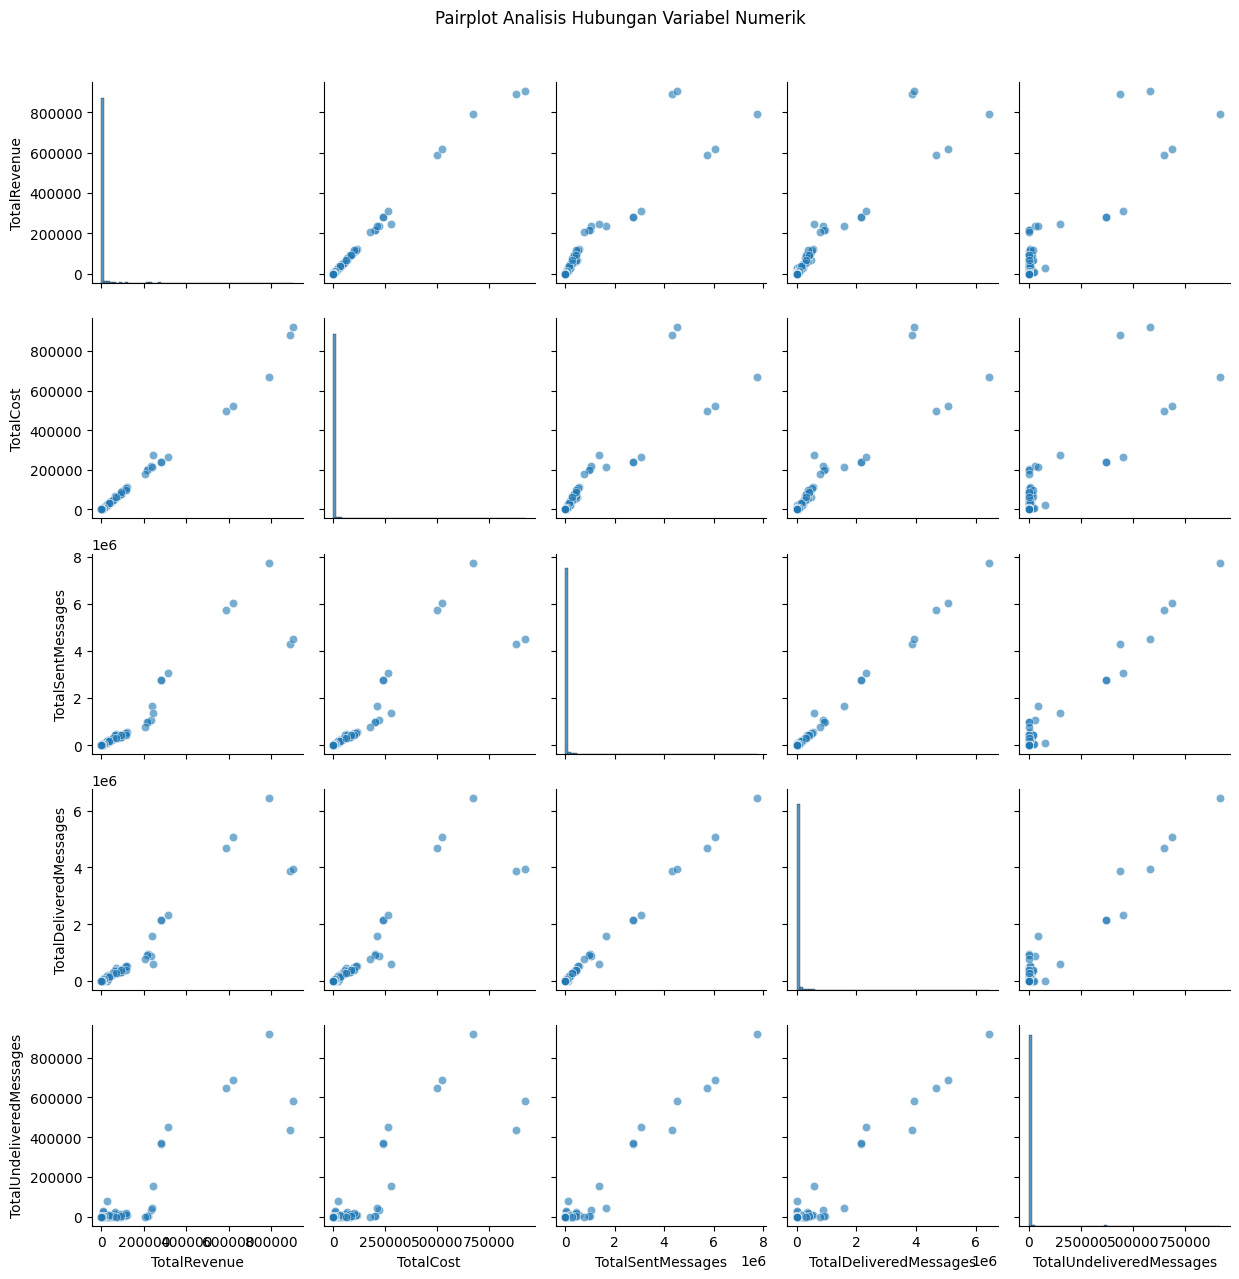

In [31]:
import seaborn as sns
# Select numeric columns from df_terurut
numeric_cols = ['TotalRevenue', 'TotalCost', 'TotalSentMessages', 'TotalDeliveredMessages', 'TotalUndeliveredMessages']

# Create a subset dataframe with numeric columns only
df_numeric = df_terurut[numeric_cols].copy()

# Convert to numeric (handle string format with commas)
for col in numeric_cols:
    df_numeric[col] = pd.to_numeric(df_numeric[col].astype(str).str.replace(',', ''), errors='coerce')

# Remove rows with NaN or 0 values for better visualization
df_numeric_clean = df_numeric[(df_numeric > 0).all(axis=1)].sample(n=min(1000, len(df_numeric)), random_state=42)

# Create pairplot
sns.pairplot(df_numeric_clean, diag_kind='hist', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Analisis Hubungan Variabel Numerik', y=1.02)
plt.tight_layout()
plt.show()

=== Matriks Korelasi Pearson ===
                          TotalRevenue  TotalCost  TotalSentMessages  \
TotalRevenue                  1.000000   0.991067           0.949424   
TotalCost                     0.991067   1.000000           0.921799   
TotalSentMessages             0.949424   0.921799           1.000000   
TotalDeliveredMessages        0.958216   0.932705           0.998874   
TotalUndeliveredMessages      0.896899   0.869555           0.968154   

                          TotalDeliveredMessages  TotalUndeliveredMessages  
TotalRevenue                            0.958216                  0.896899  
TotalCost                               0.932705                  0.869555  
TotalSentMessages                       0.998874                  0.968154  
TotalDeliveredMessages                  1.000000                  0.958897  
TotalUndeliveredMessages                0.958897                  1.000000  


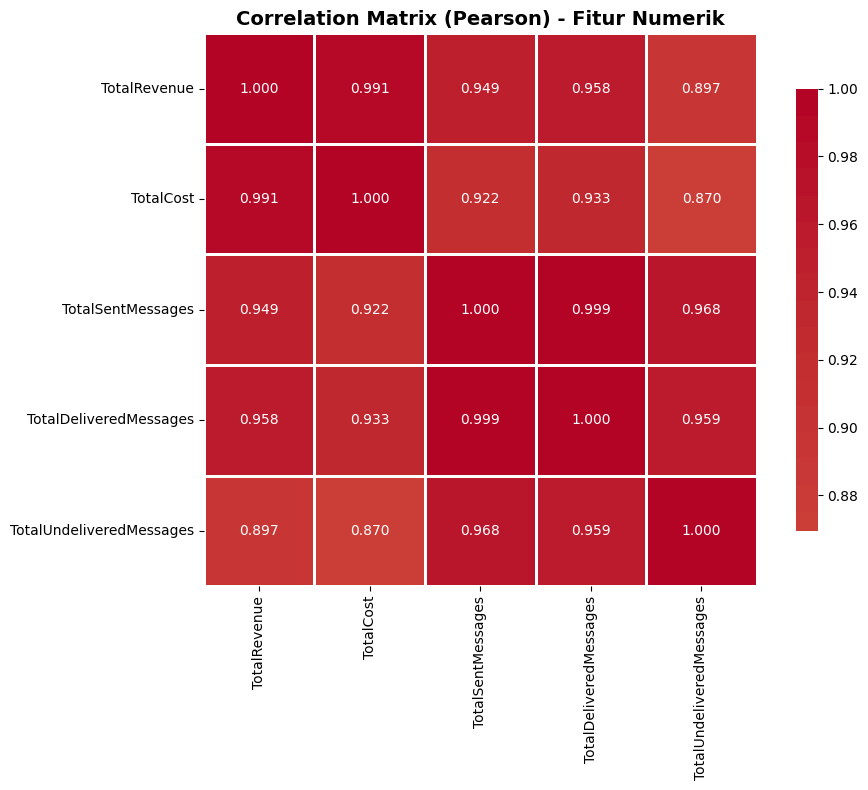


=== Korelasi dengan TotalRevenue (Descending) ===
TotalRevenue                1.000000
TotalCost                   0.991067
TotalDeliveredMessages      0.958216
TotalSentMessages           0.949424
TotalUndeliveredMessages    0.896899
Name: TotalRevenue, dtype: float64


In [32]:
# Hitung korelasi Pearson untuk fitur numerik
correlation_matrix = df_numeric.corr(method='pearson')

print("=== Matriks Korelasi Pearson ===")
print(correlation_matrix)

# Visualisasi dengan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix (Pearson) - Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tampilkan korelasi dengan TotalRevenue secara terurut
print("\n=== Korelasi dengan TotalRevenue (Descending) ===")
revenue_corr = correlation_matrix['TotalRevenue'].sort_values(ascending=False)
print(revenue_corr)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94335 entries, 0 to 94334
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Year                      94335 non-null  int64 
 1   Month                     94335 non-null  int64 
 2   Client                    94335 non-null  str   
 3   ClientConnection          94335 non-null  str   
 4   Supplier                  94335 non-null  str   
 5   SupplierConnection        94335 non-null  str   
 6   SupplierConnectionLink    94201 non-null  str   
 7   Route                     94335 non-null  str   
 8   Country                   94335 non-null  str   
 9   Network                   94335 non-null  str   
 10  OAProfiledCategory        93215 non-null  str   
 11  CostCurrency              94335 non-null  str   
 12  PriceCurrency             94335 non-null  str   
 13  ProfitCurrency            94335 non-null  str   
 14  BaseCurrency              94335 n

# EDA - Bubble Chart Series ID (Client, Supplier, Route)
Visualisasi hubungan fitur kategorikal `Client`, `Supplier`, dan `Route` melalui `Series_ID`, dengan sumbu Y adalah bulan transaksi dan ukuran bubble merepresentasikan banyaknya transaksi.

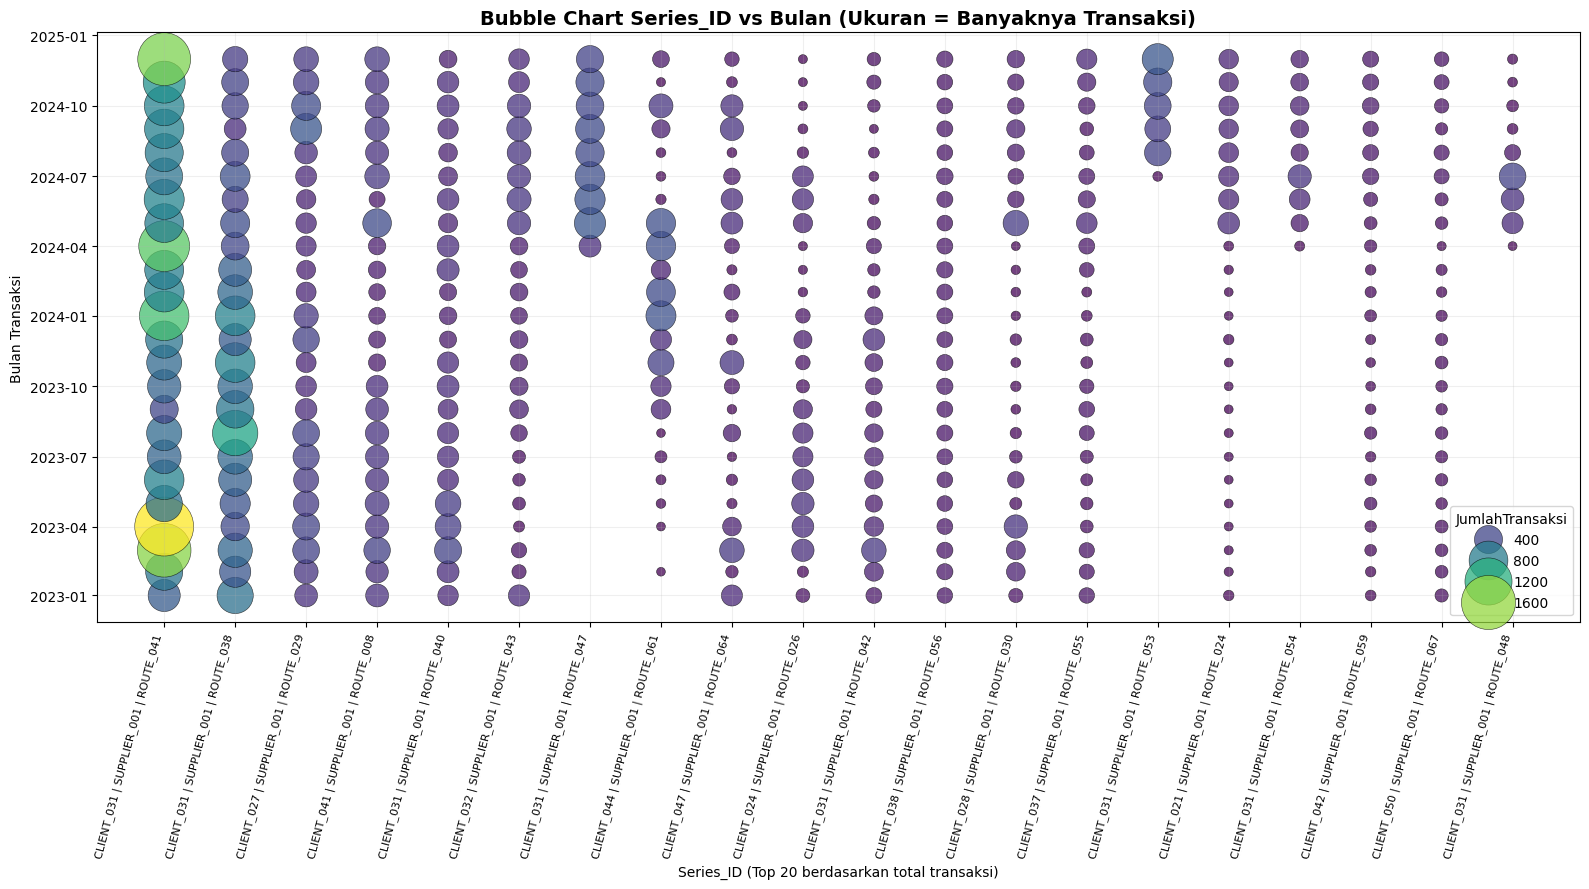

Contoh data agregasi (10 baris):


,Series_ID,MonthPeriod,JumlahTransaksi,x_pos
522,CLIENT_031 | SUPPLIER_001 | ROUTE_038,2023-01-01,693,1
586,CLIENT_031 | SUPPLIER_001 | ROUTE_041,2023-01-01,536,0
837,CLIENT_041 | SUPPLIER_001 | ROUTE_008,2023-01-01,251,3
452,CLIENT_027 | SUPPLIER_001 | ROUTE_029,2023-01-01,249,2
702,CLIENT_032 | SUPPLIER_001 | ROUTE_043,2023-01-01,212,5
924,CLIENT_047 | SUPPLIER_001 | ROUTE_064,2023-01-01,207,8
562,CLIENT_031 | SUPPLIER_001 | ROUTE_040,2023-01-01,194,4
610,CLIENT_031 | SUPPLIER_001 | ROUTE_042,2023-01-01,100,10
786,CLIENT_038 | SUPPLIER_001 | ROUTE_056,2023-01-01,95,11
762,CLIENT_037 | SUPPLIER_001 | ROUTE_055,2023-01-01,94,13


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Pastikan kolom yang dibutuhkan ada
required_cols = ['Client', 'Supplier', 'Route', 'Year', 'Month']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di dataframe: {missing_cols}")

# 2) Bentuk Series_ID dari 3 fitur kategorikal
series_df = df.copy()
for c in ['Client', 'Supplier', 'Route']:
    series_df[c] = series_df[c].fillna('UNKNOWN').astype(str)
series_df['Series_ID'] = series_df['Client'] + ' | ' + series_df['Supplier'] + ' | ' + series_df['Route']

# 3) Buat label periode bulan agar urutan 2023-2024 tetap benar
series_df['Year'] = pd.to_numeric(series_df['Year'], errors='coerce')
series_df['Month'] = pd.to_numeric(series_df['Month'], errors='coerce')
series_df = series_df.dropna(subset=['Year', 'Month'])
series_df['Year'] = series_df['Year'].astype(int)
series_df['Month'] = series_df['Month'].astype(int)
series_df['MonthPeriod'] = pd.to_datetime(
    dict(year=series_df['Year'], month=series_df['Month'], day=1),
    errors='coerce'
)
series_df = series_df.dropna(subset=['MonthPeriod'])

# 4) Agregasi jumlah transaksi per Series_ID per bulan
bubble_data = (
    series_df
    .groupby(['Series_ID', 'MonthPeriod'], as_index=False)
    .size()
    .rename(columns={'size': 'JumlahTransaksi'})
)

# 5) Ambil top series agar visual tidak terlalu padat
top_n = 20
top_series = (
    bubble_data.groupby('Series_ID', as_index=False)['JumlahTransaksi']
    .sum()
    .sort_values('JumlahTransaksi', ascending=False)
    .head(top_n)['Series_ID']
)
bubble_plot = bubble_data[bubble_data['Series_ID'].isin(top_series)].copy()

# Untuk plotting: map Series_ID ke posisi numerik
series_order = (
    bubble_plot.groupby('Series_ID')['JumlahTransaksi']
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)
series_to_x = {s: i for i, s in enumerate(series_order)}
bubble_plot['x_pos'] = bubble_plot['Series_ID'].map(series_to_x)

# 6) Bubble chart
plt.figure(figsize=(16, 9))
sns.scatterplot(
    data=bubble_plot,
    x='x_pos',
    y='MonthPeriod',
    size='JumlahTransaksi',
    hue='JumlahTransaksi',
    sizes=(40, 1800),
    palette='viridis',
    alpha=0.75,
    edgecolor='black',
    linewidth=0.4
)

plt.title('Bubble Chart Series_ID vs Bulan (Ukuran = Banyaknya Transaksi)', fontsize=14, fontweight='bold')
plt.xlabel('Series_ID (Top 20 berdasarkan total transaksi)')
plt.ylabel('Bulan Transaksi')
plt.xticks(
    ticks=range(len(series_order)),
    labels=series_order,
    rotation=75,
    ha='right',
    fontsize=8
)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('Contoh data agregasi (10 baris):')
display(bubble_plot.sort_values(['MonthPeriod', 'JumlahTransaksi'], ascending=[True, False]).head(10))

Korelasi antara TotalCost dan TotalRevenue: 0.9911


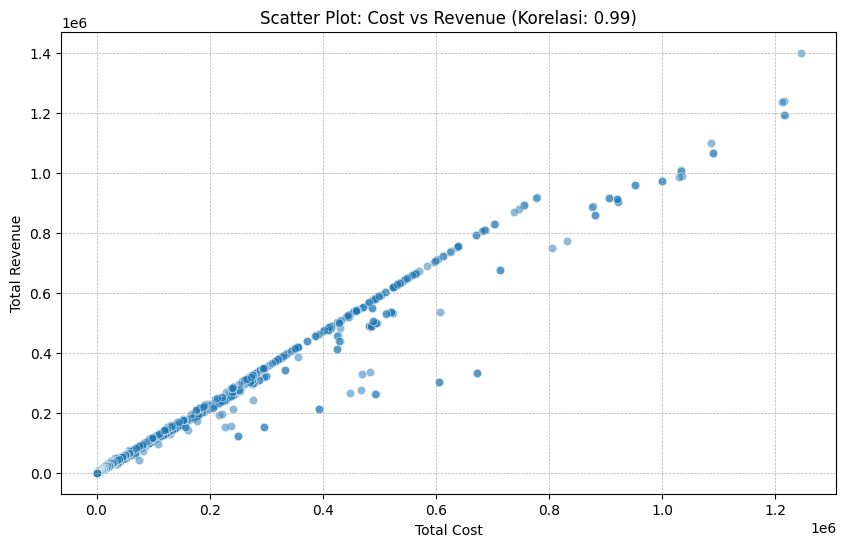

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung Koefisien Korelasi Pearson
# Nilai berkisar antara -1 sampai 1.
# 1 artinya korelasi positif sempurna (Garis lurus naik).
correlation_val = df_terurut['TotalRevenue'].corr(df_terurut['TotalCost'])

print(f"Korelasi antara TotalCost dan TotalRevenue: {correlation_val:.4f}")

# 2. Visualisasi dengan Scatter Plot
plt.figure(figsize=(10, 6))

# Menggunakan alpha=0.5 supaya kalau datanya menumpuk terlihat lebih gelap
sns.scatterplot(x=df_terurut['TotalCost'], y=df_terurut['TotalRevenue'], alpha=0.5)

# Tambahkan garis diagonal referensi (opsional, untuk melihat seberapa jauh dari lurus)
# Jika titik-titik membentuk garis lurus yang sangat rapat, berarti margin sangat konsisten.
plt.title(f'Scatter Plot: Cost vs Revenue (Korelasi: {correlation_val:.2f})')
plt.xlabel('Total Cost')
plt.ylabel('Total Revenue')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.show()

In [36]:
# Konversi kolom ke numerik (jika belum)
for col in ['TotalRevenue', 'TotalCost', 'TotalProfit']:
    df_terurut[col] = (
        df_terurut[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
        .str.replace('-', '', regex=False)
        .str.strip()
    )
    df_terurut[col] = pd.to_numeric(df_terurut[col], errors='coerce').fillna(0)

# Pola 1: Transaksi gagal (TotalRevenue=0, TotalCost=0, TotalProfit=0) -> hapus
mask_failed = (df_terurut['TotalRevenue'] == 0) & (df_terurut['TotalCost'] == 0) & (df_terurut['TotalProfit'] == 0)
count_failed = mask_failed.sum()
df_terurut = df_terurut[~mask_failed].copy()
print(f'Jumlah transaksi gagal ( Revenue=0, Cost=0, Profit=0) yang dihapus: {count_failed}')
print(f'Sisa data setelah penghapusan: {len(df_terurut)}')

# Pola 2: Bonus (TotalRevenue != 0, TotalCost = 0, TotalProfit = 0) -> is_anomaly_rev_only = 1
mask_rev_only = (df_terurut['TotalRevenue'] != 0) & (df_terurut['TotalCost'] == 0) & (df_terurut['TotalProfit'] == 0)
df_terurut['is_anomaly_rev_only'] = mask_rev_only.astype(int)
print(f'Jumlah transaksi bonus (Revenue!=0, Cost=0, Profit=0): {mask_rev_only.sum()}')

# Pola 3: Testing (TotalRevenue = 0, TotalCost != 0, TotalProfit != 0, dan Cost & Profit berkebalikan) -> is_anomaly_cost_only = 1
mask_cost_only = (df_terurut['TotalRevenue'] == 0) & (df_terurut['TotalCost'] != 0) & (df_terurut['TotalProfit'] != 0)
df_terurut['is_anomaly_cost_only'] = mask_cost_only.astype(int)
print(f'Jumlah transaksi testing (Revenue=0, Cost!=0, Profit!=0): {mask_cost_only.sum()}')

print(f'\nDistribusi is_anomaly_rev_only:')
print(df_terurut['is_anomaly_rev_only'].value_counts())
print(f'\nDistribusi is_anomaly_cost_only:')
print(df_terurut['is_anomaly_cost_only'].value_counts())

Jumlah transaksi gagal ( Revenue=0, Cost=0, Profit=0) yang dihapus: 23758
Sisa data setelah penghapusan: 70577
Jumlah transaksi bonus (Revenue!=0, Cost=0, Profit=0): 2799
Jumlah transaksi testing (Revenue=0, Cost!=0, Profit!=0): 220

Distribusi is_anomaly_rev_only:
is_anomaly_rev_only
0    67778
1     2799
Name: count, dtype: int64

Distribusi is_anomaly_cost_only:
is_anomaly_cost_only
0    70357
1      220
Name: count, dtype: int64


In [37]:
df_terurut.info()

<class 'pandas.DataFrame'>
Index: 70577 entries, 5 to 94301
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      70577 non-null  int64  
 1   Month                     70577 non-null  int64  
 2   Client                    70577 non-null  str    
 3   ClientConnection          70577 non-null  str    
 4   SupplierConnection        70577 non-null  str    
 5   SupplierConnectionLink    70521 non-null  str    
 6   Route                     70577 non-null  str    
 7   Country                   70577 non-null  str    
 8   Network                   70577 non-null  str    
 9   OAProfiledCategory        69604 non-null  str    
 10  TotalProfit               70577 non-null  float64
 11  TotalRevenue              70577 non-null  float64
 12  TotalCost                 70577 non-null  float64
 13  TotalSentMessages         70577 non-null  int64  
 14  TotalDeliveredMessages

In [38]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Copy dataframe agar aman
df_model = df_terurut.copy()
num_cols = [
    'TotalRevenue',
    'TotalCost',
    'TotalSentMessages',
    'TotalDeliveredMessages',
    'TotalUndeliveredMessages'
    # TotalProfit dihapus dari cleaning list jika tidak dipakai,
    # tapi tidak masalah dibiarkan di sini untuk cleaning saja.
]

# ======================================================
# 2. Cleaning & Imputasi
# ======================================================
for col in num_cols:
    if col in df_model.columns:
        if df_model[col].dtype == 'object':
            df_model[col] = (
                df_model[col]
                .astype(str)
                .str.replace(',', '', regex=False)
                .str.replace(' ', '', regex=False)
            )
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)

# Pastikan Month integer (Berguna untuk pola musiman 1-12)
if 'Month' in df_model.columns:
    df_model['Month'] = df_model['Month'].fillna(0).astype(int)

In [39]:
df_model.info()

<class 'pandas.DataFrame'>
Index: 70577 entries, 5 to 94301
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      70577 non-null  int64  
 1   Month                     70577 non-null  int64  
 2   Client                    70577 non-null  str    
 3   ClientConnection          70577 non-null  str    
 4   SupplierConnection        70577 non-null  str    
 5   SupplierConnectionLink    70521 non-null  str    
 6   Route                     70577 non-null  str    
 7   Country                   70577 non-null  str    
 8   Network                   70577 non-null  str    
 9   OAProfiledCategory        69604 non-null  str    
 10  TotalProfit               70577 non-null  float64
 11  TotalRevenue              70577 non-null  float64
 12  TotalCost                 70577 non-null  float64
 13  TotalSentMessages         70577 non-null  int64  
 14  TotalDeliveredMessages

In [40]:
df_model = df_model.drop(['Unnamed: 21'], axis=1, errors='ignore')

In [41]:
df = df_model.copy()

df.info()

<class 'pandas.DataFrame'>
Index: 70577 entries, 5 to 94301
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      70577 non-null  int64  
 1   Month                     70577 non-null  int64  
 2   Client                    70577 non-null  str    
 3   ClientConnection          70577 non-null  str    
 4   SupplierConnection        70577 non-null  str    
 5   SupplierConnectionLink    70521 non-null  str    
 6   Route                     70577 non-null  str    
 7   Country                   70577 non-null  str    
 8   Network                   70577 non-null  str    
 9   OAProfiledCategory        69604 non-null  str    
 10  TotalProfit               70577 non-null  float64
 11  TotalRevenue              70577 non-null  float64
 12  TotalCost                 70577 non-null  float64
 13  TotalSentMessages         70577 non-null  int64  
 14  TotalDeliveredMessages

In [42]:
print(df.columns)

Index(['Year', 'Month', 'Client', 'ClientConnection', 'SupplierConnection',
       'SupplierConnectionLink', 'Route', 'Country', 'Network',
       'OAProfiledCategory', 'TotalProfit', 'TotalRevenue', 'TotalCost',
       'TotalSentMessages', 'TotalDeliveredMessages',
       'TotalUndeliveredMessages', 'is_anomaly_rev_only',
       'is_anomaly_cost_only'],
      dtype='str')


In [43]:
df.info()

<class 'pandas.DataFrame'>
Index: 70577 entries, 5 to 94301
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Year                      70577 non-null  int64  
 1   Month                     70577 non-null  int64  
 2   Client                    70577 non-null  str    
 3   ClientConnection          70577 non-null  str    
 4   SupplierConnection        70577 non-null  str    
 5   SupplierConnectionLink    70521 non-null  str    
 6   Route                     70577 non-null  str    
 7   Country                   70577 non-null  str    
 8   Network                   70577 non-null  str    
 9   OAProfiledCategory        69604 non-null  str    
 10  TotalProfit               70577 non-null  float64
 11  TotalRevenue              70577 non-null  float64
 12  TotalCost                 70577 non-null  float64
 13  TotalSentMessages         70577 non-null  int64  
 14  TotalDeliveredMessages

In [44]:
# # ═════════════════════════════════════════════════
# # ANALISIS: Seberapa terbatas data per Series_ID?
# # ═════════════════════════════════════════════════

# df['Series_ID'] = df['Client'] + '_' + df['Route'] + '_' + df['SupplierConnection']

# # 1. Hitung jumlah bulan unik per Series_ID
# series_month_count = df.groupby('Series_ID').agg(
#     n_months=('Month', 'nunique'),
#     n_records=('Month', 'count'),
#     total_revenue=('TotalRevenue', 'sum')
# ).reset_index().sort_values('n_months', ascending=True)

# print('=== Distribusi Jumlah Bulan per Series_ID ===')
# print(series_month_count['n_months'].describe())
# print(f'\nSeries dengan hanya 1 bulan: {(series_month_count["n_months"]==1).sum()}')
# print(f'Series dengan 2-3 bulan: {((series_month_count["n_months"]>=2) & (series_month_count["n_months"]<=3)).sum()}')
# print(f'Series dengan 4-6 bulan: {((series_month_count["n_months"]>=4) & (series_month_count["n_months"]<=6)).sum()}')
# print(f'Series dengan 7-12 bulan: {((series_month_count["n_months"]>=7) & (series_month_count["n_months"]<=12)).sum()}')
# print(f'Series dengan 13-18 bulan: {((series_month_count["n_months"]>=13) & (series_month_count["n_months"]<=18)).sum()}')
# print(f'Series dengan 19-24 bulan (2 tahun): {((series_month_count["n_months"]>=19) & (series_month_count["n_months"]<=24)).sum()}')
# print(f'\nTotal Series_ID: {series_month_count["Series_ID"].nunique()}')
# print(f'Total baris data: {len(df)}')

# # 2. Range bulan per series (apakah data kontinu atau bolong-bolong?)
# all_months = sorted(df[['Year','Month']].drop_duplicates().values.tolist())
# min_month = min(df['Year']*12 + df['Month'])
# max_month = max(df['Year']*12 + df['Month'])
# total_possible_months = max_month - min_month + 1
# print(f'\n=== Range Data ===')
# print(f'Range bulan: {min_month} s/d {max_month} ({total_possible_months} bulan)')
# print(f'Rata-rata kehadiran: {series_month_count["n_months"].mean():.1f} bulan dari {total_possible_months} bulan')
# print(f'Rata-rata kehadiran (%): {series_month_count["n_months"].mean()/total_possible_months*100:.1f}%')

# # 3. Distribusi bulan per series
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# axes[0].hist(series_month_count['n_months'], bins=range(1, 26), color='steelblue', edgecolor='white')
# axes[0].set_xlabel('Jumlah Bulan Aktif')
# axes[0].set_ylabel('Jumlah Series_ID')
# axes[0].set_title('Distribusi: Berapa Bulan Setiap Series Aktif?')
# axes[0].axvline(series_month_count['n_months'].median(), color='red', ls='--', label=f'Median={series_month_count["n_months"].median():.0f}')
# axes[0].legend()

# # Revenue per series
# axes[1].hist(series_month_count['total_revenue'], bins=50, color='darkorange', edgecolor='white')
# axes[1].set_xlabel('Total Revenue per Series_ID')
# axes[1].set_ylabel('Jumlah Series_ID')
# axes[1].set_title('Distribusi: Total Revenue per Series_ID')
# axes[1].axvline(series_month_count['total_revenue'].median(), color='red', ls='--', label=f'Median={series_month_count["total_revenue"].median():.0f}')
# axes[1].legend()

# plt.tight_layout()
# plt.savefig('series_analysis.png', dpi=150, bbox_inches='tight')
# plt.show()
# print('Plot tersimpan: series_analysis.png')

In [45]:

df['Series_ID'] = df['Client'] + '_' + df['Route'] + '_' + df['SupplierConnection']
mask = df['Series_ID'] == 'CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001'
sample = df[mask][['Series_ID', 'Year', 'Month', 'Country',
                   'TotalRevenue', 'TotalCost', 'TotalProfit', 'Network']]
print(sample.to_string())
print(sample.info())

                                         Series_ID  Year  Month     Country  TotalRevenue  TotalCost  TotalProfit      Network
40     CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      3   Indonesia      774855.0   830830.0      55975.0  NETWORK_007
45     CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      3   Indonesia      750501.0   805851.0      55350.0  NETWORK_007
304    CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      3   Indonesia      243234.0   229537.0      13697.0  NETWORK_007
308    CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      3   Indonesia      238219.0   224897.0      13323.0  NETWORK_007
22     CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      4   Indonesia      905329.0   921216.0      15887.0  NETWORK_007
23     CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      4   Indonesia      904915.0   921114.0      16199.0  NETWORK_007
237    CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001  2023      4   Indonesia      323448.0   300094.0      23354

In [46]:
df

,Year,Month,Client,ClientConnection,SupplierConnection,SupplierConnectionLink,Route,Country,Network,OAProfiledCategory,TotalProfit,TotalRevenue,TotalCost,TotalSentMessages,TotalDeliveredMessages,TotalUndeliveredMessages,is_anomaly_rev_only,is_anomaly_cost_only,Series_ID
5,2023,1,CLIENT_030,CLIENTCONNECTION_071,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_037,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1391,12774.0,1098604.0,1085830.0,8516311,7900562.0,143330.0,0,0,CLIENT_030_ROUTE_037_SUPPLIERCONNECTION_001
34,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124438.0,810829.0,686391.0,7925994,6549499.0,819832.0,0,0,CLIENT_013_ROUTE_016_SUPPLIERCONNECTION_004
35,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1192,124430.0,810779.0,686348.0,7925501,6548783.0,820443.0,0,0,CLIENT_013_ROUTE_016_SUPPLIERCONNECTION_004
43,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_006,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115604.0,753265.0,637661.0,7363296,6180515.0,867061.0,0,0,CLIENT_013_ROUTE_016_SUPPLIERCONNECTION_004
44,2023,1,CLIENT_013,CLIENTCONNECTION_028,SUPPLIERCONNECTION_004,SUPPLIERCONNECTIONLINK_002,ROUTE_016,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_3758,115508.0,752645.0,637136.0,7357229,6174895.0,866668.0,0,0,CLIENT_013_ROUTE_016_SUPPLIERCONNECTION_004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94029,2024,12,CLIENT_022,CLIENTCONNECTION_092,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_075,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_2614,1.0,0.0,1.0,3,0.0,0.0,0,1,CLIENT_022_ROUTE_075_SUPPLIERCONNECTION_001
94031,2024,12,CLIENT_022,CLIENTCONNECTION_092,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_075,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_1940,2.0,0.0,2.0,7,4.0,3.0,0,1,CLIENT_022_ROUTE_075_SUPPLIERCONNECTION_001
94032,2024,12,CLIENT_022,CLIENTCONNECTION_092,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_075,Indonesia,NETWORK_007,NaN,8.0,0.0,8.0,36,20.0,16.0,0,1,CLIENT_022_ROUTE_075_SUPPLIERCONNECTION_001
94038,2024,12,CLIENT_022,CLIENTCONNECTION_092,SUPPLIERCONNECTION_001,SUPPLIERCONNECTIONLINK_001,ROUTE_075,Indonesia,NETWORK_007,OAPROFILEDCATEGORY_450,2.0,0.0,2.0,9,9.0,0.0,0,1,CLIENT_022_ROUTE_075_SUPPLIERCONNECTION_001


# Enhanced Month Aggregation
Agregasi bulanan yang ditingkatkan dengan fitur-fitur berikut:
- **TotalProfit** & **profit_margin**: profitabilitas per Series_ID per bulan
- **delivery_rate**: kualitas pengiriman SMS (delivered/sent)
- **is_anomaly_rev_only/cost_only** & **anomaly_count**: flag anomali yang sebelumnya hilang
- **anomaly_revenue_pct**: rasio transaksi anomali terhadap total
- **unique_OA_count**: jumlah kategori OA (keragaman sub-transaksi)
- **max_OA_revenue** & **min_OA_revenue**: distribusi revenue antar OA profile
- **rateCost**: dihitung ulang dari SUM (bukan mean) agar lebih akurat

# Complete Panel: Series_ID × Semua Bulan
**Mengapa perlu panel lengkap?**
- Data asli hanya berisi bulan yang ADA transaksi → lag features salah (skip bulan kosong)
- Model tidak belajar bahwa series bisa dormant/idle
- Dengan panel lengkap: setiap Series_ID punya baris untuk SEMUA bulan dalam dataset
- Bulan tanpa transaksi diisi Revenue=0, `is_active=0`
- Sekarang lag_1 = benar-benar bulan sebelumnya (termasuk yang idle)

In [47]:
# Perbaiki Series_ID — masukkan Network
df['Series_ID'] = (df['Client'] + '_' + df['Route'] + '_' +
                   df['SupplierConnection'] + '_' + df['Network'])
print(f"Jumlah Series_ID unik: {df['Series_ID'].nunique()}")

# Country DIKELUARKAN dari group_cols
group_cols = ['Series_ID', 'Year', 'Month',
              'Client', 'Route', 'SupplierConnection', 'Network']  # <-- Country dihapus

# --- Step 1: Aggregate raw transactions per Series_ID × Year × Month ---
oa_rev = df.groupby(group_cols + ['OAProfiledCategory'])['TotalRevenue'].sum().reset_index()
oa_stats = oa_rev.groupby(group_cols)['TotalRevenue'].agg(['max', 'min']).reset_index()
oa_stats = oa_stats.rename(columns={'max': 'max_OA_revenue', 'min': 'min_OA_revenue'})

anom_rev = df.groupby(group_cols).agg(
    total_rows=('TotalRevenue', 'count'),
    anomaly_rev_rows=('is_anomaly_rev_only', 'sum')
).reset_index()
anom_rev['anomaly_revenue_pct'] = np.where(
    anom_rev['total_rows'] > 0,
    anom_rev['anomaly_rev_rows'] / anom_rev['total_rows'], 0
)

agg_dict = {
    'TotalRevenue': 'sum',
    'TotalCost': 'sum',
    'TotalProfit': 'sum',
    'TotalSentMessages': 'sum',
    'TotalDeliveredMessages': 'sum',
    'TotalUndeliveredMessages': 'sum',
    'is_anomaly_rev_only': 'sum',
    'is_anomaly_cost_only': 'sum',
    'OAProfiledCategory': 'nunique',
}

monthly = df.groupby(group_cols, as_index=False).agg(agg_dict)
monthly = monthly.rename(columns={'OAProfiledCategory': 'unique_OA_count'})

monthly = monthly.merge(oa_stats, on=group_cols, how='left')
monthly = monthly.merge(anom_rev[group_cols + ['anomaly_revenue_pct']], on=group_cols, how='left')

# --- Step 2: Create COMPLETE panel (Series_ID × all months) ---
# Country DIKELUARKAN dari all_series
all_series = df[['Series_ID', 'Client', 'Route', 'SupplierConnection', 'Network']].drop_duplicates()  # <-- Country dihapus
all_months = sorted(df[['Year', 'Month']].drop_duplicates().values.tolist())
month_df = pd.DataFrame(all_months, columns=['Year', 'Month'])

# Cross join: every series × every month
panel = all_series.merge(month_df, how='cross')

# Merge actual data
panel = panel.merge(monthly, on=group_cols, how='left')

# Compute anomaly_count
panel['anomaly_count'] = panel['is_anomaly_rev_only'].fillna(0) + panel['is_anomaly_cost_only'].fillna(0)

# --- Step 3: Fill missing months ---
fill_zero_cols = ['TotalRevenue', 'TotalCost', 'TotalProfit',
                 'TotalSentMessages', 'TotalDeliveredMessages', 'TotalUndeliveredMessages',
                 'is_anomaly_rev_only', 'is_anomaly_cost_only', 'unique_OA_count',
                 'max_OA_revenue', 'min_OA_revenue']
for col in fill_zero_cols:
    if col in panel.columns:
        panel[col] = panel[col].fillna(0)

panel['anomaly_revenue_pct'] = panel['anomaly_revenue_pct'].fillna(0)
panel['is_active'] = (panel['TotalRevenue'] > 0).astype(int)

panel['rateCost'] = np.where(
    panel['TotalDeliveredMessages'] > 0,
    panel['TotalCost'] / panel['TotalDeliveredMessages'], 0)
panel['profit_margin'] = np.where(
    panel['TotalRevenue'] > 0,
    panel['TotalProfit'] / panel['TotalRevenue'], 0)
panel['delivery_rate'] = np.where(
    panel['TotalSentMessages'] > 0,
    panel['TotalDeliveredMessages'] / panel['TotalSentMessages'], 0)

panel = panel.sort_values(['Series_ID', 'Year', 'Month']).reset_index(drop=True)
monthly = panel.copy()

# Verifikasi — harus 2.184 baris, maks 1 per slot
dup = monthly.groupby(['Series_ID', 'Year', 'Month']).size()
print(f'Complete panel shape: {monthly.shape}')          # (2184, ...)
print(f'Unique Series_ID: {monthly["Series_ID"].nunique()}')  # 91
print(f'Maks baris per slot: {dup.max()}')               # 1
print(f'Active months: {monthly["is_active"].sum()}')
print(f'Idle months: {(monthly["is_active"]==0).sum()}')
print(f'is_active ratio: {monthly["is_active"].mean()*100:.1f}%')

Jumlah Series_ID unik: 91
Complete panel shape: (2184, 24)
Unique Series_ID: 91
Maks baris per slot: 1
Active months: 1031
Idle months: 1153
is_active ratio: 47.2%


In [48]:
dup = monthly.groupby(['Series_ID', 'Year', 'Month']).size()
print(f"Maks baris per Series_ID per bulan: {dup.max()}")
print(f"Jumlah slot duplikat: {(dup > 1).sum()}")

# Lihat siapa yang duplikat
print(dup[dup > 1].head(10))

Maks baris per Series_ID per bulan: 1
Jumlah slot duplikat: 0
Series([], dtype: int64)


# Distribusi Pendapatan per Series ID
Histogram total revenue per series (dijumlahkan seluruh bulan) dan histogram revenue bulanan untuk melihat sebaran nilai — apakah merata atau ada series yang sangat dominan.

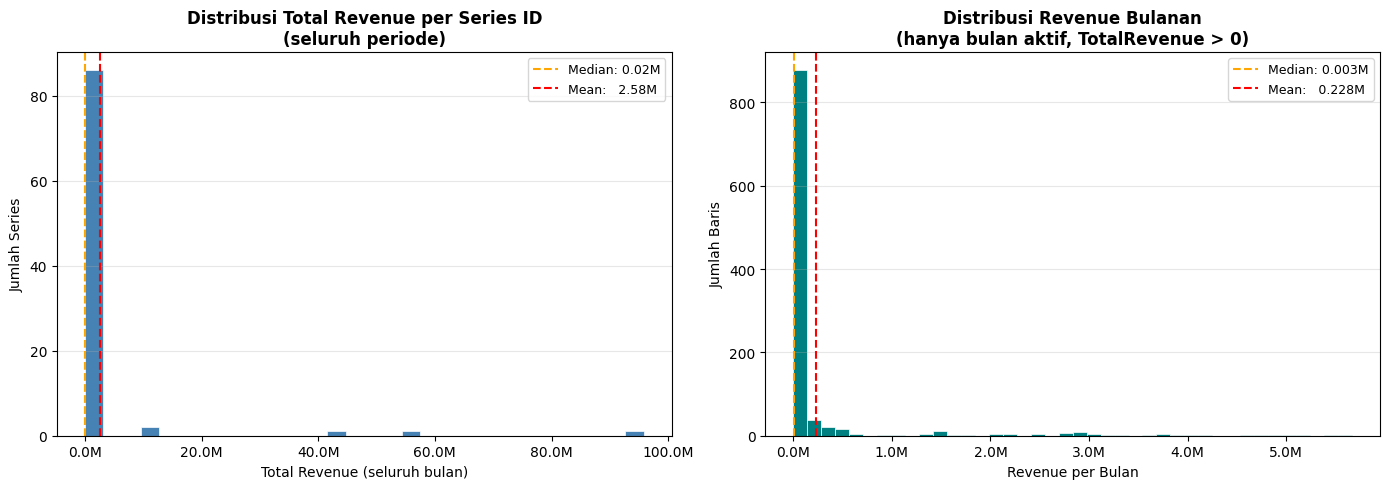

Jumlah series: 91
Total revenue — min: 0 | median: 21,453 | max: 95,796,601
Series dengan revenue 0: 2
Top 5 series by revenue:
Series_ID
CLIENT_013_ROUTE_016_SUPPLIERCONNECTION_004_NETWORK_007    95796601.0
CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007    54768875.0
CLIENT_031_ROUTE_041_SUPPLIERCONNECTION_001_NETWORK_007    43164416.0
CLIENT_031_ROUTE_038_SUPPLIERCONNECTION_001_NETWORK_007    10039871.0
CLIENT_031_ROUTE_040_SUPPLIERCONNECTION_001_NETWORK_007     9887294.0


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Total revenue per Series_ID (jumlah seluruh bulan)
series_total = monthly.groupby('Series_ID')['TotalRevenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Kiri: Histogram total revenue per Series_ID ──
axes[0].hist(series_total.values, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Total Revenue per Series ID\n(seluruh periode)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue (seluruh bulan)')
axes[0].set_ylabel('Jumlah Series')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].grid(axis='y', alpha=0.3)

# Garis median & mean
axes[0].axvline(series_total.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {series_total.median()/1e6:.2f}M')
axes[0].axvline(series_total.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean:   {series_total.mean()/1e6:.2f}M')
axes[0].legend(fontsize=9)

# ── Kanan: Histogram revenue bulanan (semua baris aktif) ──
active_rev = monthly.loc[monthly['TotalRevenue'] > 0, 'TotalRevenue']
axes[1].hist(active_rev.values, bins=40, color='teal', edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Revenue Bulanan\n(hanya bulan aktif, TotalRevenue > 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Revenue per Bulan')
axes[1].set_ylabel('Jumlah Baris')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[1].grid(axis='y', alpha=0.3)

axes[1].axvline(active_rev.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {active_rev.median()/1e6:.3f}M')
axes[1].axvline(active_rev.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean:   {active_rev.mean()/1e6:.3f}M')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('distribusi_revenue_series.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Jumlah series: {len(series_total)}')
print(f'Total revenue — min: {series_total.min():,.0f} | median: {series_total.median():,.0f} | max: {series_total.max():,.0f}')
print(f'Series dengan revenue 0: {(series_total == 0).sum()}')
print(f'Top 5 series by revenue:')
print(series_total.head().to_string())

In [50]:
# Apakah ada Series_ID yang punya lebih dari 1 Network atau Country?
print(df.groupby('Series_ID')['Network'].nunique().value_counts())
print(df.groupby('Series_ID')['Country'].nunique().value_counts())

# Cek duplikasi per bulan
dup = monthly.groupby(['Series_ID', 'Year', 'Month']).size()
print(f"\nMaks baris per Series_ID per bulan: {dup.max()}")
print(f"Series_ID yang punya >1 baris per bulan: {(dup > 1).sum()}")

Network
1    91
Name: count, dtype: int64
Country
1    90
2     1
Name: count, dtype: int64

Maks baris per Series_ID per bulan: 1
Series_ID yang punya >1 baris per bulan: 0


In [51]:
# Lihat series yang punya 2 network - apakah revenue-nya beda jauh?
multi_network = df.groupby('Series_ID')['Network'].nunique()
multi_series = multi_network[multi_network > 1].index

sample = (monthly[monthly['Series_ID'].isin(multi_series)]
          .groupby(['Series_ID', 'Network'])['TotalRevenue']
          .sum()
          .reset_index())
print(sample.head(20))

Empty DataFrame
Columns: [Series_ID, Network, TotalRevenue]
Index: []


In [52]:
mask = df['Series_ID'] == 'CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007'
sample = df[mask][['Series_ID', 'Year', 'Month', 'Country',
                   'TotalRevenue', 'TotalCost', 'TotalProfit']].head(10)
print(sample.to_string())

                                                   Series_ID  Year  Month    Country  TotalRevenue  TotalCost  TotalProfit
40   CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      3  Indonesia      774855.0   830830.0      55975.0
45   CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      3  Indonesia      750501.0   805851.0      55350.0
304  CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      3  Indonesia      243234.0   229537.0      13697.0
308  CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      3  Indonesia      238219.0   224897.0      13323.0
22   CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      4  Indonesia      905329.0   921216.0      15887.0
23   CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      4  Indonesia      904915.0   921114.0      16199.0
237  CLIENT_017_ROUTE_020_SUPPLIERCONNECTION_001_NETWORK_007  2023      4  Indonesia      323448.0   300094.0      23354.0
238  CLIENT_017_

In [53]:
print(f"Total baris: {len(monthly)}")
print(f"Baris revenue > 0: {(monthly['TotalRevenue'] > 0).sum()}")
print(f"Baris revenue = 0: {(monthly['TotalRevenue'] == 0).sum()}")

# Cek apakah ada kombinasi bulan yang tidak muncul
from itertools import product
all_months = monthly['Month'].unique()
all_series = monthly    ['Series_ID'].unique()
expected_rows = len(all_months) * len(all_series)
print(f"\nBaris yang ada: {len(monthly)}")
print(f"Baris yang seharusnya (72 × 24): {expected_rows}")
print(f"Baris yang hilang: {expected_rows - len(monthly)}")

Total baris: 2184
Baris revenue > 0: 1031
Baris revenue = 0: 1153

Baris yang ada: 2184
Baris yang seharusnya (72 × 24): 1092
Baris yang hilang: -1092


In [54]:
# ═══════════════════════════════════════════════
# STEP 2 — FEATURE ENGINEERING
# ═══════════════════════════════════════════════

monthly = monthly.sort_values(['Series_ID', 'Year', 'Month']).reset_index(drop=True)

# ── Lag features ──
for lag in [1, 2, 3]:
    monthly[f'rev_lag{lag}'] = monthly.groupby('Series_ID')['TotalRevenue'].shift(lag)
    monthly[f'active_lag{lag}'] = monthly.groupby('Series_ID')['is_active'].shift(lag)

# ── Rolling features (shift(1) dulu supaya tidak bocor data bulan ini) ──
grp_rev = monthly.groupby('Series_ID')['TotalRevenue']
monthly['rolling_mean_3'] = grp_rev.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
monthly['rolling_mean_6'] = grp_rev.shift(1).rolling(6).mean().reset_index(level=0, drop=True)
monthly['rolling_std_3']  = grp_rev.shift(1).rolling(3).std().reset_index(level=0, drop=True)
monthly['rolling_std_6']  = grp_rev.shift(1).rolling(6).std().reset_index(level=0, drop=True)

grp_act = monthly.groupby('Series_ID')['is_active']
monthly['pct_active_3m'] = grp_act.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
monthly['pct_active_6m'] = grp_act.shift(1).rolling(6).mean().reset_index(level=0, drop=True)

# ── Streak aktif berturut-turut ──
def active_streak(s):
    streak, count = [], 0
    for val in s.shift(1).fillna(0):
        count = count + 1 if val == 1 else 0
        streak.append(count)
    return pd.Series(streak, index=s.index)

monthly['active_streak'] = monthly.groupby('Series_ID', group_keys=False)['is_active'].apply(active_streak)

# ── Bulan sejak terakhir aktif ──
def months_since_active(s):
    result, count = [], 0
    for val in s.shift(1).fillna(0):
        count = 0 if val == 1 else count + 1
        result.append(count)
    return pd.Series(result, index=s.index)

monthly['months_since_active'] = monthly.groupby('Series_ID', group_keys=False)['is_active'].apply(months_since_active)

# ── Month sebagai fitur siklikalitas ──
monthly['month_sin'] = np.sin(2 * np.pi * monthly['Month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['Month'] / 12)

# ── Target: bulan DEPAN ──
monthly['target_active']  = monthly.groupby('Series_ID')['is_active'].shift(-1)
monthly['target_revenue'] = monthly.groupby('Series_ID')['TotalRevenue'].shift(-1)

# Buang baris terakhir tiap series (tidak ada target)
monthly = monthly[monthly['target_active'].notna()].reset_index(drop=True)

# Cek hasil
print(f"Shape setelah feature engineering: {monthly.shape}")
print(f"Baris untuk Stage 1 (semua): {len(monthly)}")
print(f"Baris untuk Stage 2 (aktif saja): {int(monthly['target_active'].sum())}")
print(f"\nNaN di fitur utama:")
feat_cols = ['rev_lag1','rev_lag2','rev_lag3',
             'rolling_mean_3','rolling_mean_6',
             'pct_active_3m','pct_active_6m',
             'active_streak','months_since_active']
print(monthly[feat_cols].isnull().sum())

Shape setelah feature engineering: (2093, 42)
Baris untuk Stage 1 (semua): 2093
Baris untuk Stage 2 (aktif saja): 994

NaN di fitur utama:
rev_lag1                91
rev_lag2               182
rev_lag3               273
rolling_mean_3         273
rolling_mean_6         546
pct_active_3m          273
pct_active_6m          546
active_streak            0
months_since_active      0
dtype: int64


In [55]:
# ═══════════════════════════════════════════════
# STEP 3 — IMPUTASI & PERSIAPAN FITUR FINAL
# ═══════════════════════════════════════════════

# Fillna 0 untuk lag dan rolling (awal series memang tidak ada histori)
lag_roll_cols = ['rev_lag1', 'rev_lag2', 'rev_lag3',
                 'active_lag1', 'active_lag2', 'active_lag3',
                 'rolling_mean_3', 'rolling_mean_6',
                 'rolling_std_3', 'rolling_std_6',
                 'pct_active_3m', 'pct_active_6m']

for col in lag_roll_cols:
    if col in monthly.columns:
        monthly[col] = monthly[col].fillna(0)

# Definisi fitur untuk tiap stage
FEATURES_STAGE1 = [
    # Status historis (paling penting untuk klasifikasi)
    'active_lag1', 'active_lag2', 'active_lag3',
    'active_streak', 'months_since_active',
    'pct_active_3m', 'pct_active_6m',
    # Revenue historis
    'rev_lag1', 'rev_lag2', 'rev_lag3',
    'rolling_mean_3', 'rolling_mean_6',
    # Operasional
    'TotalSentMessages', 'TotalDeliveredMessages',
    'delivery_rate', 'unique_OA_count',
    # Anomali
    'anomaly_count', 'anomaly_revenue_pct',
    # Siklikalitas
    'month_sin', 'month_cos',
]

FEATURES_STAGE2 = [
    # Revenue historis (paling penting untuk regresi)
    'rev_lag1', 'rev_lag2', 'rev_lag3',
    'rolling_mean_3', 'rolling_mean_6',
    'rolling_std_3', 'rolling_std_6',
    # Status historis
    'active_lag1', 'active_lag2',
    'active_streak', 'pct_active_3m', 'pct_active_6m',
    # Operasional & margin
    'TotalSentMessages', 'TotalDeliveredMessages',
    'delivery_rate', 'profit_margin', 'rateCost',
    'unique_OA_count', 'max_OA_revenue',
    # Anomali
    'anomaly_count', 'anomaly_revenue_pct',
    # Siklikalitas
    'month_sin', 'month_cos',
]

# Verifikasi tidak ada NaN tersisa
print("NaN Stage 1 features:")
print(monthly[FEATURES_STAGE1].isnull().sum()[monthly[FEATURES_STAGE1].isnull().sum() > 0])
print("\nNaN Stage 2 features:")
print(monthly[FEATURES_STAGE2].isnull().sum()[monthly[FEATURES_STAGE2].isnull().sum() > 0])

print(f"\nTotal fitur Stage 1: {len(FEATURES_STAGE1)}")
print(f"Total fitur Stage 2: {len(FEATURES_STAGE2)}")
print(f"\nData siap modeling:")
print(f"  Stage 1 — semua baris: {len(monthly)}")
print(f"  Stage 2 — hanya aktif: {int(monthly['target_active'].sum())}")

NaN Stage 1 features:
Series([], dtype: int64)

NaN Stage 2 features:
Series([], dtype: int64)

Total fitur Stage 1: 20
Total fitur Stage 2: 23

Data siap modeling:
  Stage 1 — semua baris: 2093
  Stage 2 — hanya aktif: 994


In [56]:
monthly.to_csv('monthly_panel.csv', index=False)

In [57]:
monthly.info()

<class 'pandas.DataFrame'>
RangeIndex: 2093 entries, 0 to 2092
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Series_ID                 2093 non-null   str    
 1   Client                    2093 non-null   str    
 2   Route                     2093 non-null   str    
 3   SupplierConnection        2093 non-null   str    
 4   Network                   2093 non-null   str    
 5   Year                      2093 non-null   int64  
 6   Month                     2093 non-null   int64  
 7   TotalRevenue              2093 non-null   float64
 8   TotalCost                 2093 non-null   float64
 9   TotalProfit               2093 non-null   float64
 10  TotalSentMessages         2093 non-null   float64
 11  TotalDeliveredMessages    2093 non-null   float64
 12  TotalUndeliveredMessages  2093 non-null   float64
 13  is_anomaly_rev_only       2093 non-null   float64
 14  is_anomaly_cost_onl

In [58]:
# # ═══════════════════════════════════════════════
# # STEP 4 — TIME SERIES SPLIT + STAGE 1 MODELING
# # ═══════════════════════════════════════════════
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import (classification_report, roc_auc_score,
#                              precision_recall_curve, average_precision_score)
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# # ── Time-based split (bukan random!) ──
# # Train: bulan 1-18, Test: bulan 19-23 (5 bulan terakhir)
# # Pakai kolom period untuk urutan kronologis
# monthly['period'] = monthly['Year'] * 12 + monthly['Month']
# cutoff = monthly['period'].quantile(0.80).astype(int)  # 80% train, 20% test

# train = monthly[monthly['period'] <= cutoff].copy()
# test  = monthly[monthly['period'] >  cutoff].copy()

# print(f"Train: {len(train)} baris | period {train['period'].min()}–{train['period'].max()}")
# print(f"Test:  {len(test)} baris  | period {test['period'].min()}–{test['period'].max()}")
# print(f"\nTrain active ratio: {train['target_active'].mean():.2%}")
# print(f"Test  active ratio: {test['target_active'].mean():.2%}")

# X_train_s1 = train[FEATURES_STAGE1]
# y_train_s1 = train['target_active'].astype(int)
# X_test_s1  = test[FEATURES_STAGE1]
# y_test_s1  = test['target_active'].astype(int)

# # ── Model Stage 1: LightGBM Classifier ──
# clf = lgb.LGBMClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     num_leaves=31,
#     min_child_samples=10,   # penting untuk data kecil
#     class_weight='balanced', # handle imbalance aktif vs idle
#     random_state=42,
#     verbose=-1
# )
# clf.fit(X_train_s1, y_train_s1,
#         eval_set=[(X_test_s1, y_test_s1)],
#         callbacks=[lgb.early_stopping(50, verbose=False)])

# # ── Evaluasi Stage 1 ──
# y_pred_s1      = clf.predict(X_test_s1)
# y_prob_s1      = clf.predict_proba(X_test_s1)[:, 1]

# print("\n── Stage 1: Classification Report ──")
# print(classification_report(y_test_s1, y_pred_s1, target_names=['Idle','Active']))
# print(f"ROC-AUC:          {roc_auc_score(y_test_s1, y_prob_s1):.4f}")
# print(f"Average Precision: {average_precision_score(y_test_s1, y_prob_s1):.4f}")

# # Feature importance
# fi_s1 = pd.DataFrame({
#     'feature': FEATURES_STAGE1,
#     'importance': clf.feature_importances_
# }).sort_values('importance', ascending=False)
# print("\n── Top 10 Feature Importance Stage 1 ──")
# print(fi_s1.head(10).to_string(index=False))

In [59]:
# ═══════════════════════════════════════════════
# STEP 4 — TIME SERIES SPLIT + STAGE 1 MODELING
# ═══════════════════════════════════════════════
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, average_precision_score)
import warnings
warnings.filterwarnings('ignore')
# ── Model Stage 1: XGBoost Classifier ──
from xgboost import XGBClassifier


# ── Time-based split (bukan random!) ──
# Train: bulan 1-18, Test: bulan 19-23 (5 bulan terakhir)
# Pakai kolom period untuk urutan kronologis
monthly['period'] = monthly['Year'] * 12 + monthly['Month']
cutoff = monthly['period'].quantile(0.80).astype(int)  # 80% train, 20% test

train = monthly[monthly['period'] <= cutoff].copy()
test  = monthly[monthly['period'] >  cutoff].copy()

print(f"Train: {len(train)} baris | period {train['period'].min()}–{train['period'].max()}")
print(f"Test:  {len(test)} baris  | period {test['period'].min()}–{test['period'].max()}")
print(f"\nTrain active ratio: {train['target_active'].mean():.2%}")
print(f"Test  active ratio: {test['target_active'].mean():.2%}")

X_train_s1 = train[FEATURES_STAGE1]
y_train_s1 = train['target_active'].astype(int)
X_test_s1  = test[FEATURES_STAGE1]
y_test_s1  = test['target_active'].astype(int)

clf = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.3,
    max_depth=6,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_lambda=1.0,
    scale_pos_weight=(y_train_s1 == 0).sum() / (y_train_s1 == 1).sum(),  # handle imbalance
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50,
    verbosity=0,
)
clf.fit(X_train_s1, y_train_s1,
        eval_set=[(X_test_s1, y_test_s1)],
        verbose=False)


# ── Evaluasi Stage 1 ──
y_pred_s1      = clf.predict(X_test_s1)
y_prob_s1      = clf.predict_proba(X_test_s1)[:, 1]

print("\n── Stage 1: Classification Report ──")
print(classification_report(y_test_s1, y_pred_s1, target_names=['Idle','Active']))
print(f"ROC-AUC:          {roc_auc_score(y_test_s1, y_prob_s1):.4f}")
print(f"Average Precision: {average_precision_score(y_test_s1, y_prob_s1):.4f}")

# Feature importance
fi_s1 = pd.DataFrame({
    'feature': FEATURES_STAGE1,
    'importance': clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\n── Top 10 Feature Importance Stage 1 ──")
print(fi_s1.head(10).to_string(index=False))

Train: 1729 baris | period 24277–24295
Test:  364 baris  | period 24296–24299

Train active ratio: 45.23%
Test  active ratio: 58.24%

── Stage 1: Classification Report ──
              precision    recall  f1-score   support

        Idle       0.91      0.92      0.92       152
      Active       0.94      0.93      0.94       212

    accuracy                           0.93       364
   macro avg       0.93      0.93      0.93       364
weighted avg       0.93      0.93      0.93       364

ROC-AUC:          0.9611
Average Precision: 0.9748

── Top 10 Feature Importance Stage 1 ──
               feature  importance
     TotalSentMessages    0.561195
       unique_OA_count    0.120060
   months_since_active    0.038720
         active_streak    0.035611
TotalDeliveredMessages    0.032204
         pct_active_6m    0.026792
        rolling_mean_3    0.025367
         anomaly_count    0.019282
         delivery_rate    0.016042
              rev_lag2    0.014865


In [60]:
# ═══════════════════════════════════════════════
# STEP 5 — STAGE 2: REGRESI + GA TUNING (PyGAD)
# ═══════════════════════════════════════════════
import pygad
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


# ── WMAPE function ──
def wmape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual))

# ── Siapkan data Stage 2 ──
train_s2 = train[train['target_active'] == 1].copy()
test_s2  = test[clf.predict(X_test_s1) == 1].copy()

X_train_s2 = train_s2[FEATURES_STAGE2].values
y_train_s2 = train_s2['target_revenue'].values
X_test_s2  = test_s2[FEATURES_STAGE2].values
y_test_s2  = test_s2['target_revenue'].values

print(f"Stage 2 - Train: {len(X_train_s2)} baris")
print(f"Stage 2 - Test:  {len(X_test_s2)} baris")

N_FEATURES = len(FEATURES_STAGE2)

# ═══════════════════════════════════════════════
# HYPERPARAMETER SPACE — RANGE KONTINU
# ══════════════════════════════════════════════

# ── Random Forest ──
RF_GENE_SPACE = [
    {'low': 50,  'high': 1000},        # n_estimators     (Int)
    {'low': 1,   'high': 7},           # max_depth         (Int)
    {'low': 2,   'high': 20},          # min_samples_split (Int)
    {'low': 1,   'high': 50},          # min_samples_leaf  (Int)
    {'low': 1,   'high': N_FEATURES},  # max_features      (Int)
    {'low': 0.1, 'high': 1.0},         # max_samples       (Float)
]

def decode_rf(solution):
    return {
        'n_estimators':      int(round(solution[0])),
        'max_depth':         int(round(solution[1])),
        'min_samples_split': int(round(solution[2])),
        'min_samples_leaf':  int(round(solution[3])),
        'max_features':      int(round(solution[4])),
        'max_samples':       float(np.clip(solution[5], 0.1, 1.0)),
    }

# ── XGBoost ──
XGB_GENE_SPACE = [
    {'low': 0.001, 'high': 1.0},   # learning_rate  (Float)
    {'low': 50,    'high': 1000},  # n_estimators   (Int)
    {'low': 1,     'high': 7},     # max_depth      (Int)
    {'low': 0.1,   'high': 1.0},   # subsample      (Float)
    {'low': 0.1,   'high': 1.0},   # colsample_bytree (Float)
    {'low': 1,     'high': 3},     # reg_lambda     (Float)
]


def decode_xgb(solution):
    return {
        'learning_rate':     float(np.clip(solution[0], 0.001, 1.0)),
        'n_estimators':      int(round(solution[1])),
        'max_depth':         int(round(solution[2])),
        'subsample':         float(np.clip(solution[3], 0.1, 1.0)),
        'colsample_bytree':  float(np.clip(solution[4], 0.1, 1.0)),
        'reg_lambda':        float(np.clip(solution[5], 1, 3)),
    }

# ═══════════════════════════════════════════════
# FITNESS FUNCTIONS — WMAPE
# ═══════════════════════════════════════════════

def fitness_rf(ga_instance, solution, solution_idx):
    params = decode_rf(solution)
    model  = RandomForestRegressor(**params, random_state=42, n_jobs=1)
    model.fit(X_train_s2, y_train_s2)
    pred   = model.predict(X_test_s2)
    return -wmape(y_test_s2, pred)
def fitness_xgb(ga_instance, solution, solution_idx):
    params = decode_xgb(solution)
    model = XGBRegressor(**params, random_state=42, verbosity=0)
    model.fit(X_train_s2, y_train_s2)
    pred = model.predict(X_test_s2)
    score = wmape(y_test_s2, pred)
    return -score  # PyGAD maximize → negatif WMAPE


# ── Callback untuk monitoring konvergensi ──
def on_generation(ga):
    if ga.generations_completed % 10 == 0:
        print(f"  Gen {ga.generations_completed:>3} | "
              f"Best WMAPE: {-ga.best_solution()[1]:.4f}")

# ═══════════════════════════════════════════════
# RUN GA — RANDOM FOREST
# ═══════════════════════════════════════════════
print("Running GA untuk Random Forest...")
print(f"{'Gen':>6} | {'Best WMAPE':>12}")

ga_rf = pygad.GA(
    num_generations=200,
    num_parents_mating=4,
    fitness_func=fitness_rf,
    sol_per_pop=40,
    num_genes=6,
    gene_space=RF_GENE_SPACE,
    mutation_percent_genes=20,
    crossover_type='scattered',
    parent_selection_type='tournament',
    K_tournament=3,
    mutation_type='random',
    keep_elitism=4,
    on_generation=on_generation,
    random_seed=42,
)
ga_rf.run()

best_sol_rf, best_fit_rf, _ = ga_rf.best_solution()
best_params_rf = decode_rf(best_sol_rf)
print(f"\nBest params RF   : {best_params_rf}")
print(f"Best WMAPE RF    : {-best_fit_rf:.4f} ({-best_fit_rf*100:.2f}%)")

# ═══════════════════════════════════════════════
# RUN GA — XGBOOST
# ═══════════════════════════════════════════════
print("\nRunning GA untuk XGBoost...")
print(f"{'Gen':>6} | {'Best WMAPE':>12}")

ga_xgb = pygad.GA(
    num_generations=200,
    num_parents_mating=4,
    fitness_func=fitness_xgb,
    sol_per_pop=40,
    num_genes=6,
    gene_space=XGB_GENE_SPACE,
    mutation_percent_genes=20,
    crossover_type='scattered',
    parent_selection_type='tournament',
    K_tournament=3,
    mutation_type='random',
    keep_elitism=4,
    on_generation=on_generation,
    random_seed=42,
)
ga_xgb.run()

best_sol_xgb, best_fit_xgb, _ = ga_xgb.best_solution()
best_params_xgb = decode_xgb(best_sol_xgb)
print(f"\nBest params XGB  : {best_params_xgb}")
print(f"Best WMAPE XGB   : {-best_fit_xgb:.4f} ({-best_fit_xgb*100:.2f}%)")

# ═══════════════════════════════════════════════
# EVALUASI FINAL — 4 MODEL
# ═══════════════════════════════════════════════
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred      = model.predict(X_te)
    mae       = mean_absolute_error(y_te, pred)
    rmse      = np.sqrt(mean_squared_error(y_te, pred))
    r2        = r2_score(y_te, pred)
    wmape_val = wmape(y_te, pred)
    mape      = np.mean(np.abs((y_te - pred) /
                  np.where(y_te == 0, 1, y_te))) * 100
    print(f"\n{name}")
    print(f"  MAE   : {mae:>14.2f}")
    print(f"  RMSE  : {rmse:>14.2f}")
    print(f"  R²    : {r2:>14.4f}")
    print(f"  WMAPE : {wmape_val*100:>13.2f}%")
    print(f"  MAPE  : {mape:>13.2f}%")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse,
            'R2': r2, 'WMAPE(%)': wmape_val*100, 'MAPE(%)': mape}

print("\n" + "═"*50)
print("HASIL PERBANDINGAN 4 MODEL — STAGE 2")
print("═"*50)

results = []
results.append(evaluate(
    "RF Baseline",
    RandomForestRegressor(random_state=42, n_jobs=-1),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))
results.append(evaluate(
    "RF + GA",
    RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))
results.append(evaluate(
    "XGBoost Baseline",
    XGBRegressor(random_state=42, verbosity=0),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))
results.append(evaluate(
    "XGBoost + GA",
    XGBRegressor(**best_params_xgb, random_state=42, verbosity=0),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))

results_df = pd.DataFrame(results)
print("\n══ Tabel Ringkasan ══")
print(results_df.to_string(index=False))
print(f"\nModel terbaik (WMAPE): "
      f"{results_df.loc[results_df['WMAPE(%)'].idxmin(), 'Model']}")

Stage 2 - Train: 782 baris
Stage 2 - Test:  210 baris
Running GA untuk Random Forest...
   Gen |   Best WMAPE
  Gen  10 | Best WMAPE: 0.2162
  Gen  20 | Best WMAPE: 0.2148
  Gen  30 | Best WMAPE: 0.2148
  Gen  40 | Best WMAPE: 0.2099
  Gen  50 | Best WMAPE: 0.2099
  Gen  60 | Best WMAPE: 0.2099
  Gen  70 | Best WMAPE: 0.2099
  Gen  80 | Best WMAPE: 0.2099
  Gen  90 | Best WMAPE: 0.2097
  Gen 100 | Best WMAPE: 0.2097
  Gen 110 | Best WMAPE: 0.2097
  Gen 120 | Best WMAPE: 0.2097
  Gen 130 | Best WMAPE: 0.2062
  Gen 140 | Best WMAPE: 0.2015
  Gen 150 | Best WMAPE: 0.2001
  Gen 160 | Best WMAPE: 0.2001
  Gen 170 | Best WMAPE: 0.2001
  Gen 180 | Best WMAPE: 0.2001
  Gen 190 | Best WMAPE: 0.1935
  Gen 200 | Best WMAPE: 0.1935

Best params RF   : {'n_estimators': 51, 'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 8, 'max_samples': 0.7577805254854454}
Best WMAPE RF    : 0.1935 (19.35%)

Running GA untuk XGBoost...
   Gen |   Best WMAPE
  Gen  10 | Best WMAPE: 0.

In [61]:
# ═══════════════════════════════════════════════
# EVALUASI BASELINE — TANPA GA
# (jalankan setelah GA selesai)
# ═══════════════════════════════════════════════

def wmape(actual, pred):
    return np.sum(np.abs(actual - pred)) / np.sum(np.abs(actual))

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred      = model.predict(X_te)
    mae       = mean_absolute_error(y_te, pred)
    rmse      = np.sqrt(mean_squared_error(y_te, pred))
    r2        = r2_score(y_te, pred)
    wmape_val = wmape(y_te, pred)
    mape      = np.mean(np.abs((y_te - pred) /
                  np.where(y_te == 0, 1, y_te))) * 100
    print(f"\n{name}")
    print(f"  MAE   : {mae:>14.2f}")
    print(f"  RMSE  : {rmse:>14.2f}")
    print(f"  R²    : {r2:>14.4f}")
    print(f"  WMAPE : {wmape_val*100:>13.2f}%")
    print(f"  MAPE  : {mape:>13.2f}%")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse,
            'R2': r2, 'WMAPE(%)': wmape_val*100, 'MAPE(%)': mape}

print("═"*50)
print("BASELINE — DEFAULT HYPERPARAMETER (TANPA GA)")
print("═"*50)

results = []

# RF Baseline
results.append(evaluate(
    "RF Baseline (default)",
    RandomForestRegressor(random_state=42, n_jobs=-1),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))

# XGBoost Baseline
results.append(evaluate(
    "XGBoost Baseline (default)",
    XGBRegressor(random_state=42, verbosity=0),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))

# Setelah GA selesai, tambahkan hasil GA ke sini
results.append(evaluate(
    "RF + GA",
    RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))

results.append(evaluate(
    "XGBoost + GA",
    XGBRegressor(**best_params_xgb, random_state=42, verbosity=0),
    X_train_s2, y_train_s2, X_test_s2, y_test_s2
))

# Tabel ringkasan
results_df = pd.DataFrame(results)
print("\n══ Tabel Perbandingan Lengkap ══")
print(results_df.to_string(index=False))
print(f"\nModel terbaik (WMAPE): "
      f"{results_df.loc[results_df['WMAPE(%)'].idxmin(), 'Model']}")

# Improvement GA vs Baseline
print("\n══ Improvement GA vs Baseline ══")
rf_base  = results_df[results_df['Model']=='RF Baseline (default)']['WMAPE(%)'].values[0]
rf_ga    = results_df[results_df['Model']=='RF + GA']['WMAPE(%)'].values[0]
xgb_base = results_df[results_df['Model']=='XGBoost Baseline (default)']['WMAPE(%)'].values[0]
xgb_ga   = results_df[results_df['Model']=='XGBoost + GA']['WMAPE(%)'].values[0]

print(f"RF    : {rf_base:.2f}% → {rf_ga:.2f}% "
      f"({'↓' if rf_ga < rf_base else '↑'} "
      f"{abs(rf_base - rf_ga):.2f}pp)")
print(f"XGBoost: {xgb_base:.2f}% → {xgb_ga:.2f}% "
      f"({'↓' if xgb_ga < xgb_base else '↑'} "
      f"{abs(xgb_base - xgb_ga):.2f}pp)")

══════════════════════════════════════════════════
BASELINE — DEFAULT HYPERPARAMETER (TANPA GA)
══════════════════════════════════════════════════

RF Baseline (default)
  MAE   :       36451.29
  RMSE  :      119799.38
  R²    :         0.9396
  WMAPE :         25.37%
  MAPE  :     276064.82%

XGBoost Baseline (default)
  MAE   :       38969.10
  RMSE  :      135905.08
  R²    :         0.9222
  WMAPE :         27.12%
  MAPE  :     184865.54%

RF + GA
  MAE   :       27796.81
  RMSE  :       95072.06
  R²    :         0.9619
  WMAPE :         19.35%
  MAPE  :     126467.47%

XGBoost + GA
  MAE   :       23398.93
  RMSE  :       74683.89
  R²    :         0.9765
  WMAPE :         16.29%
  MAPE  :     102138.62%

══ Tabel Perbandingan Lengkap ══
                     Model          MAE          RMSE       R2  WMAPE(%)       MAPE(%)
     RF Baseline (default) 36451.286274 119799.383000 0.939555 25.369518 276064.820365
XGBoost Baseline (default) 38969.102955 135905.079269 0.922210 27.12187

In [62]:
print(type(ga_rf.best_solutions_fitness))
print(ga_rf.best_solutions_fitness[:5])
print(len(ga_rf.best_solutions_fitness))

<class 'list'>
[np.float64(-0.24920866544531706), np.float64(-0.24434624878825123), np.float64(-0.231736282045479), np.float64(-0.22759378251251522), np.float64(-0.21616454297303067)]
201


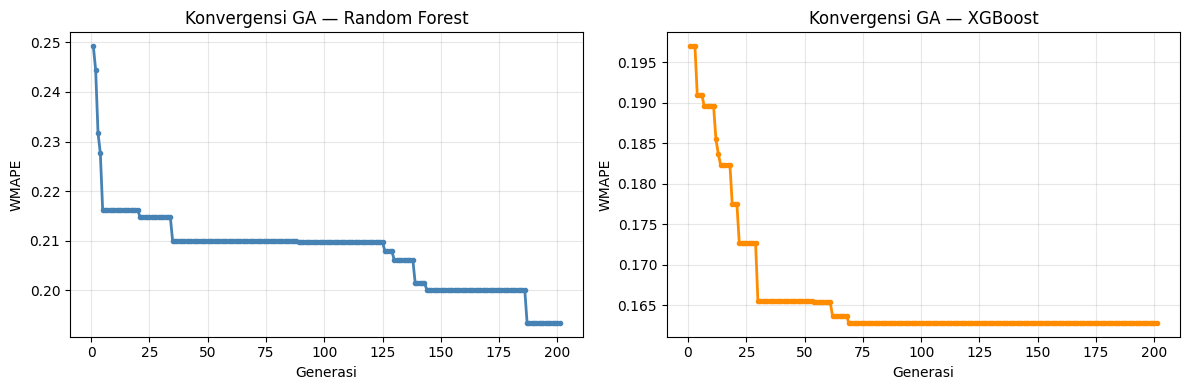

In [63]:
import matplotlib.pyplot as plt

# Ambil fitness terbaik per generasi dengan benar
rf_fitness  = [-min(gen) if hasattr(gen, '__iter__')
               else -gen for gen in ga_rf.best_solutions_fitness]
xgb_fitness = [-min(gen) if hasattr(gen, '__iter__')
               else -gen for gen in ga_xgb.best_solutions_fitness]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(rf_fitness)+1), rf_fitness,
             color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Konvergensi GA — Random Forest')
axes[0].set_xlabel('Generasi')
axes[0].set_ylabel('WMAPE')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(xgb_fitness)+1), xgb_fitness,
             color='darkorange', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Konvergensi GA — XGBoost')
axes[1].set_xlabel('Generasi')
axes[1].set_ylabel('WMAPE')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('konvergensi_ga.png', dpi=150, bbox_inches='tight')
plt.show()

══════════════════════════════════════════════════════════════════════
TRAIN vs TEST METRICS — Deteksi Overfitting / Underfitting
══════════════════════════════════════════════════════════════════════
                   Train MAE    Test MAE   Train RMSE    Test RMSE  Train R²  Test R²  Train WMAPE  Test WMAPE
Model                                                                                                         
RF Baseline       23236.5488  36451.2863   88448.0440  119799.3830    0.9880   0.9396       9.3490     25.3695
RF + GA           35700.9388  27796.8096  119641.1299   95072.0622    0.9781   0.9619      14.3639     19.3461
XGBoost Baseline   5797.3576  38969.1030   66305.8018  135905.0793    0.9933   0.9222       2.3325     27.1219
XGBoost + GA      24867.9572  23398.9343   81510.7844   74683.8919    0.9898   0.9765      10.0053     16.2853


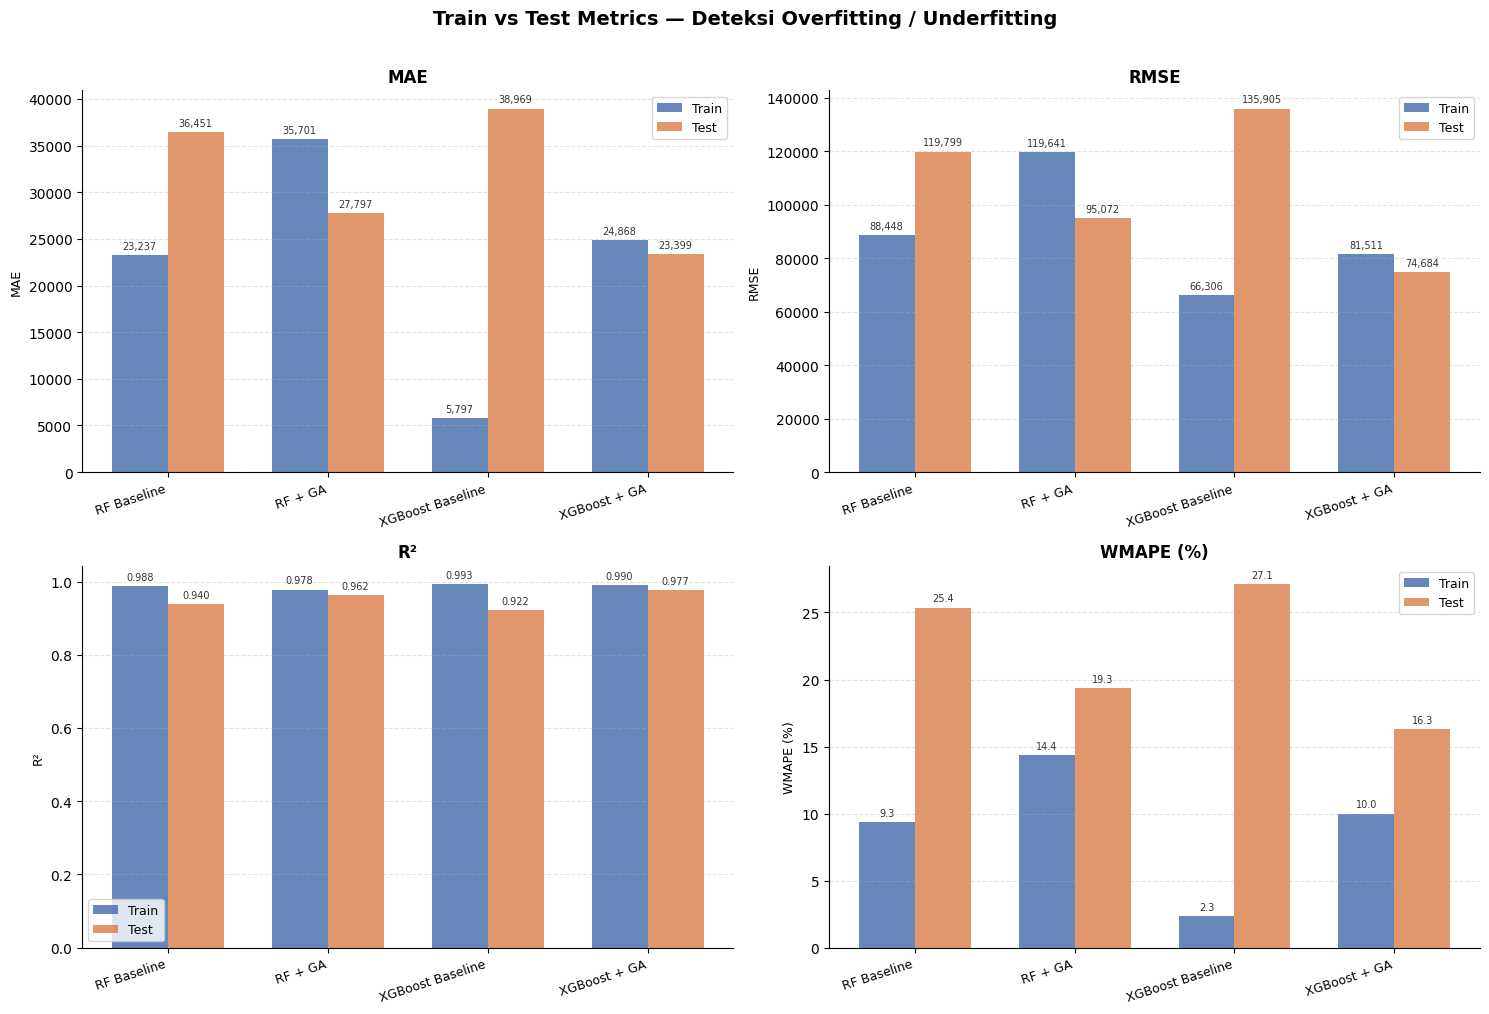


Keterangan interpretasi:
  Train ≈ Test (keduanya baik)   → Generalisasi baik ✓
  Train jauh lebih baik dari Test → Overfit (model hafal data latih) ✗
  Train ≈ Test (keduanya buruk)   → Underfit (model terlalu sederhana) ✗


In [64]:
# ═══════════════════════════════════════════════
# STEP — DETEKSI OVERFITTING / UNDERFITTING
# Train vs Test Metrics per Model
# ═══════════════════════════════════════════════

def evaluate_train_test(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    def _m(y, pred):
        mae  = mean_absolute_error(y, pred)
        rmse = np.sqrt(mean_squared_error(y, pred))
        r2   = r2_score(y, pred)
        wm   = wmape(y, pred) * 100
        return mae, rmse, r2, wm

    tr = _m(y_tr, pred_tr)
    te = _m(y_te, pred_te)
    return {
        'Model':       name,
        'Train MAE':   tr[0], 'Test MAE':   te[0],
        'Train RMSE':  tr[1], 'Test RMSE':  te[1],
        'Train R²':    tr[2], 'Test R²':    te[2],
        'Train WMAPE': tr[3], 'Test WMAPE': te[3],
    }

models_ov = [
    ('RF Baseline',      RandomForestRegressor(random_state=42, n_jobs=-1)),
    ('RF + GA',          RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)),
    ('XGBoost Baseline', XGBRegressor(random_state=42, verbosity=0)),
    ('XGBoost + GA',     XGBRegressor(**best_params_xgb, random_state=42, verbosity=0)),
]

ov_results = [evaluate_train_test(n, m, X_train_s2, y_train_s2, X_test_s2, y_test_s2)
              for n, m in models_ov]
ov_df = pd.DataFrame(ov_results).set_index('Model')

print('═' * 70)
print('TRAIN vs TEST METRICS — Deteksi Overfitting / Underfitting')
print('═' * 70)
print(ov_df[['Train MAE','Test MAE','Train RMSE','Test RMSE',
             'Train R²','Test R²','Train WMAPE','Test WMAPE']].round(4).to_string())

# ── Plot grouped bar: Train vs Test untuk 4 metrik ──
metric_cfg = [
    ('MAE',       'Train MAE',   'Test MAE',   ',.0f'),
    ('RMSE',      'Train RMSE',  'Test RMSE',  ',.0f'),
    ('R²',        'Train R²',    'Test R²',    '.3f'),
    ('WMAPE (%)', 'Train WMAPE', 'Test WMAPE', '.1f'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Train vs Test Metrics — Deteksi Overfitting / Underfitting',
             fontsize=14, fontweight='bold', y=1.01)

model_names = ov_df.index.tolist()
x     = np.arange(len(model_names))
width = 0.35
C_TR  = '#4C72B0'
C_TE  = '#DD8452'

for ax, (title, tr_col, te_col, fmt) in zip(axes.flatten(), metric_cfg):
    bars_tr = ax.bar(x - width/2, ov_df[tr_col], width, label='Train', color=C_TR, alpha=0.85)
    bars_te = ax.bar(x + width/2, ov_df[te_col], width, label='Test',  color=C_TE, alpha=0.85)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=18, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.set_ylabel(title, fontsize=9)
    ax.grid(axis='y', alpha=0.35, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    for bar in list(bars_tr) + list(bars_te):
        v = bar.get_height()
        lbl = format(v, fmt)
        ax.annotate(lbl,
                    xy=(bar.get_x() + bar.get_width() / 2, v),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=7, color='#333333')

plt.tight_layout()
plt.savefig('overfit_check.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKeterangan interpretasi:')
print('  Train ≈ Test (keduanya baik)   → Generalisasi baik ✓')
print('  Train jauh lebih baik dari Test → Overfit (model hafal data latih) ✗')
print('  Train ≈ Test (keduanya buruk)   → Underfit (model terlalu sederhana) ✗')


In [65]:
# ═══════════════════════════════════════════════
# STEP 5b — STATISTIK DISTRIBUSI ABSOLUTE ERROR TIAP MODEL
# ═══════════════════════════════════════════════
from scipy.stats import iqr as scipy_iqr

models_for_eval = [
    ("RF Baseline (default)",      RandomForestRegressor(random_state=42, n_jobs=-1)),
    ("RF + GA",                    RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)),
    ("XGBoost Baseline (default)", XGBRegressor(random_state=42, verbosity=0)),
    ("XGBoost + GA",               XGBRegressor(**best_params_xgb, random_state=42, verbosity=0)),
]

error_stats = []
for name, model in models_for_eval:
    model.fit(X_train_s2, y_train_s2)
    pred    = model.predict(X_test_s2)
    abs_err = np.abs(y_test_s2 - pred)
    error_stats.append({
        'Model' : name,
        'Mean'  : abs_err.mean(),
        'Median': np.median(abs_err),
        'Std'   : abs_err.std(),

        'IQR'   : scipy_iqr(abs_err),
        'Min'   : abs_err.min(),
        'Max'   : abs_err.max(),
    })

err_df = pd.DataFrame(error_stats)
print("══ Statistik Absolute Error Tiap Model (Test Set) ══")
print(err_df.round(2).to_string(index=False))
print(f"\nModel paling stabil (Std terkecil) : {err_df.loc[err_df['Std'].idxmin(), 'Model']}")
print(f"Model median error terkecil        : {err_df.loc[err_df['Median'].idxmin(), 'Model']}")

══ Statistik Absolute Error Tiap Model (Test Set) ══
                     Model     Mean  Median       Std      IQR   Min        Max
     RF Baseline (default) 36451.29 8293.15 114119.22 22498.25  2.29 1322174.08
                   RF + GA 27796.81 6194.06  90917.73 10579.03 75.90  961339.57
XGBoost Baseline (default) 38969.10 7748.00 130198.31 24139.62 51.67 1170168.75
              XGBoost + GA 23398.93 4466.73  70923.72 11938.61 89.01  758899.62

Model paling stabil (Std terkecil) : XGBoost + GA
Model median error terkecil        : XGBoost + GA


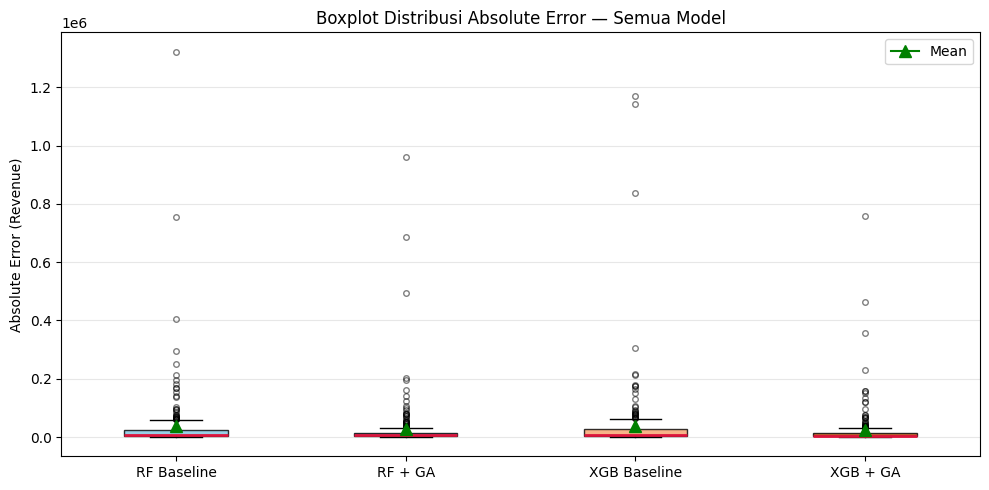


══ Perubahan Error: Baseline → GA-Tuned ══
Indeks      RF Base      RF+GA     Δ RF     XGB Base     XGB+GA  Δ XGB
  Mean    36,451.29  27,796.81   -23.7%    38,969.10  23,398.93 -40.0%
Median     8,293.15   6,194.06   -25.3%     7,748.00   4,466.73 -42.3%
   Std   114,119.22  90,917.73   -20.3%   130,198.31  70,923.72 -45.5%
   IQR    22,498.25  10,579.03   -53.0%    24,139.62  11,938.61 -50.5%
   Min         2.29      75.90 +3214.6%        51.67      89.01 +72.3%
   Max 1,322,174.08 961,339.57   -27.3% 1,170,168.75 758,899.62 -35.1%


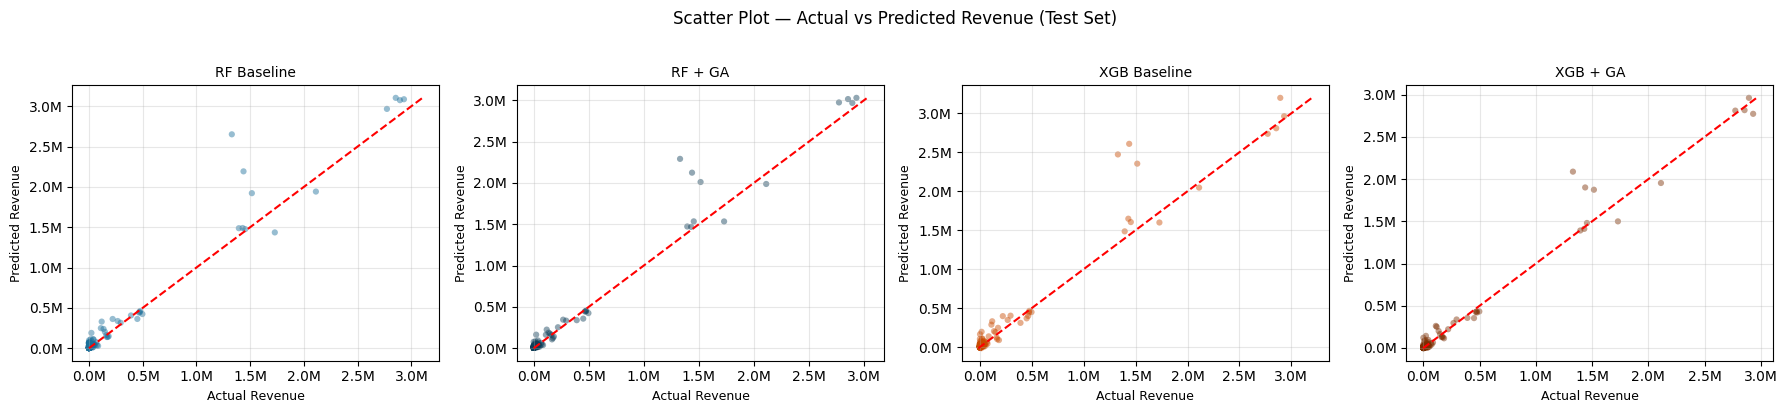

In [66]:
# ═══════════════════════════════════════════════
# STEP 5c — VISUALISASI: BOXPLOT, TABEL PERUBAHAN, SCATTER PLOT
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import iqr as scipy_iqr

# ── Re-fit semua model & kumpulkan prediksi ──────────────────────────────
models_viz = [
    ("RF Baseline",  RandomForestRegressor(random_state=42, n_jobs=-1)),
    ("RF + GA",      RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)),
    ("XGB Baseline", XGBRegressor(random_state=42, verbosity=0)),
    ("XGB + GA",     XGBRegressor(**best_params_xgb, random_state=42, verbosity=0)),
]

preds_dict  = {}
errors_dict = {}
for name, model in models_viz:
    model.fit(X_train_s2, y_train_s2)
    pred = model.predict(X_test_s2)
    preds_dict[name]  = pred
    errors_dict[name] = np.abs(y_test_s2 - pred)

# ── 1. BOXPLOT DISTRIBUSI ABSOLUTE ERROR ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

labels = list(errors_dict.keys())
data   = [errors_dict[k] for k in labels]
colors_bp = ['#7fc4e0', '#1a6e99', '#f5a06b', '#c94a00']

bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color='crimson', linewidth=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.5))

for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, d in enumerate(data, 1):
    ax.plot(i, np.mean(d), marker='^', color='green', markersize=9, zorder=5, label='Mean' if i == 1 else '')

ax.set_xticks(range(1, 5))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Absolute Error (Revenue)')
ax.set_title('Boxplot Distribusi Absolute Error — Semua Model', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('boxplot_error_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. TABEL PERUBAHAN (%) BASELINE → GA ─────────────────────────────────
def get_stats(arr):
    return {
        'Mean'  : arr.mean(),
        'Median': np.median(arr),
        'Std'   : arr.std(),
        'IQR'   : scipy_iqr(arr),
        'Min'   : arr.min(),
        'Max'   : arr.max(),
    }

def pct_chg(base, new):
    return f"{(new - base) / base * 100:+.1f}%" if base != 0 else "—"

rf_b  = get_stats(errors_dict['RF Baseline'])
rf_g  = get_stats(errors_dict['RF + GA'])
xb_b  = get_stats(errors_dict['XGB Baseline'])
xb_g  = get_stats(errors_dict['XGB + GA'])

rows = []
for k in ['Mean', 'Median', 'Std', 'IQR', 'Min', 'Max']:
    rows.append({
        'Indeks'      : k,
        'RF Base'     : f"{rf_b[k]:,.2f}",
        'RF+GA'       : f"{rf_g[k]:,.2f}",
        'Δ RF'        : pct_chg(rf_b[k], rf_g[k]),
        'XGB Base'    : f"{xb_b[k]:,.2f}",
        'XGB+GA'      : f"{xb_g[k]:,.2f}",
        'Δ XGB'       : pct_chg(xb_b[k], xb_g[k]),
    })

change_df = pd.DataFrame(rows)
print("\n══ Perubahan Error: Baseline → GA-Tuned ══")
print(change_df.to_string(index=False))

# ── 3. SCATTER PLOT ACTUAL VS PREDICTED ──────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

scatter_colors = ['#1a6e99', '#0d3d57', '#c94a00', '#7a2d00']

for ax, (name, _), color in zip(axes, models_viz, scatter_colors):
    pred = preds_dict[name]
    ax.scatter(y_test_s2, pred, alpha=0.45, color=color, s=20, edgecolors='none')
    lo = min(y_test_s2.min(), pred.min())
    hi = max(y_test_s2.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
    ax.set_xlabel('Actual Revenue', fontsize=9)
    ax.set_ylabel('Predicted Revenue', fontsize=9)
    ax.set_title(name, fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plot — Actual vs Predicted Revenue (Test Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('scatter_actual_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

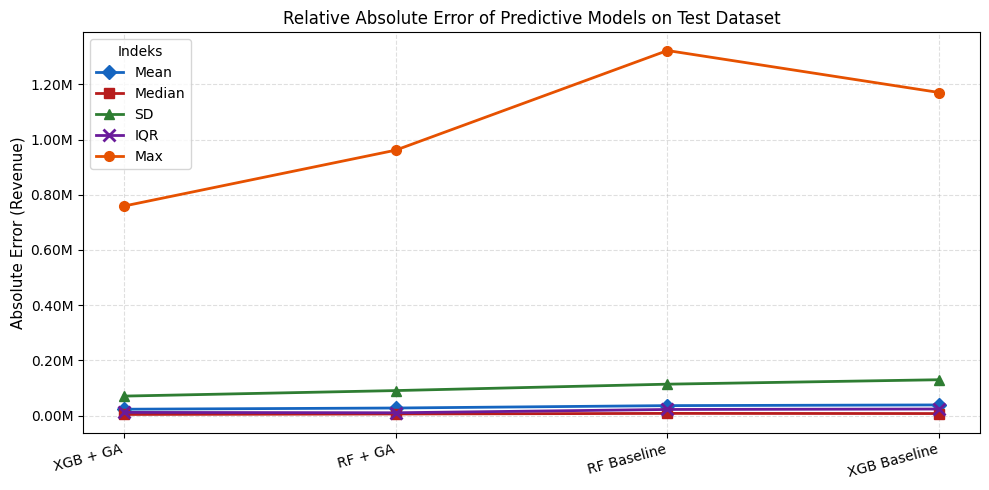


══ Nilai yang Diplot (Absolute Error per Indeks) ══
                  Mean   Median         SD       IQR         Max
XGB + GA      23398.93  4466.73   70923.72  11938.61   758899.62
RF + GA       27796.81  6194.06   90917.73  10579.03   961339.57
RF Baseline   36451.29  8293.15  114119.22  22498.25  1322174.08
XGB Baseline  38969.10  7748.00  130198.31  24139.62  1170168.75


In [67]:
# ═══════════════════════════════════════════════
# STEP 5d — RELATIVE ABSOLUTE ERROR: LINE CHART STATISTIK
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import iqr as scipy_iqr

# ── Hitung statistik error tiap model (gunakan errors_dict dari Step 5c) ─
stat_indices = {
    'Mean'  : lambda e: e.mean(),
    'Median': lambda e: np.median(e),
    'SD'    : lambda e: e.std(),
    'IQR'   : lambda e: scipy_iqr(e),
    'Max'   : lambda e: e.max(),
}

model_order_sorted = sorted(errors_dict.keys(), key=lambda m: errors_dict[m].mean())

stat_values = {stat: [fn(errors_dict[m]) for m in model_order_sorted]
               for stat, fn in stat_indices.items()}

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

styles = {
    'Mean'  : dict(color='#1565c0', marker='D', linestyle='-',  linewidth=2, markersize=7),
    'Median': dict(color='#b71c1c', marker='s', linestyle='-',  linewidth=2, markersize=7),
    'SD'    : dict(color='#2e7d32', marker='^', linestyle='-',  linewidth=2, markersize=7),
    'IQR'   : dict(color='#6a1b9a', marker='x', linestyle='-', linewidth=2, markersize=9, markeredgewidth=2),
    'Max'   : dict(color='#e65100', marker='o', linestyle='-',  linewidth=2, markersize=7),
}

for stat, vals in stat_values.items():
    ax.plot(range(len(model_order_sorted)), vals, label=stat, **styles[stat])

ax.set_xticks(range(len(model_order_sorted)))
ax.set_xticklabels(model_order_sorted, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Absolute Error (Revenue)', fontsize=11)
ax.set_title('Relative Absolute Error of Predictive Models on Test Dataset', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.legend(title='Indeks', loc='upper left', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('relative_absolute_error.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabel nilai yang diplot ───────────────────────────────────────────────
import pandas as pd
rae_df = pd.DataFrame(stat_values, index=model_order_sorted)
print("\n══ Nilai yang Diplot (Absolute Error per Indeks) ══")
print(rae_df.round(2).to_string())

Stage 2 model digunakan : XGBoost + GA
Train size (aktif)      : 994 baris

Bulan aktual terakhir  : 12/2024
Forecast periode       : 01/2025 – 03/2025

  Jan 2025  →  Aktif:   49 series  |  Total Revenue:     7,585,320.83
  Feb 2025  →  Aktif:   50 series  |  Total Revenue:     7,823,480.14
  Mar 2025  →  Aktif:   50 series  |  Total Revenue:     7,539,185.77

═════════════════════════════════════════════════════════════════
RINGKASAN FORECAST JAN–MAR 2025
═════════════════════════════════════════════════════════════════
Month_Name  N_Active  N_Total  Active_Rate_pct  Total_Revenue  Avg_Rev_per_Active
       Jan        49       91             53.8     7585320.83           154802.47
       Feb        50       91             54.9     7823480.16           156469.60
       Mar        50       91             54.9     7539185.78           150783.72

Total Revenue Kumulatif  :   22,947,986.77
Rata-rata aktif/bulan    :            49.7 series


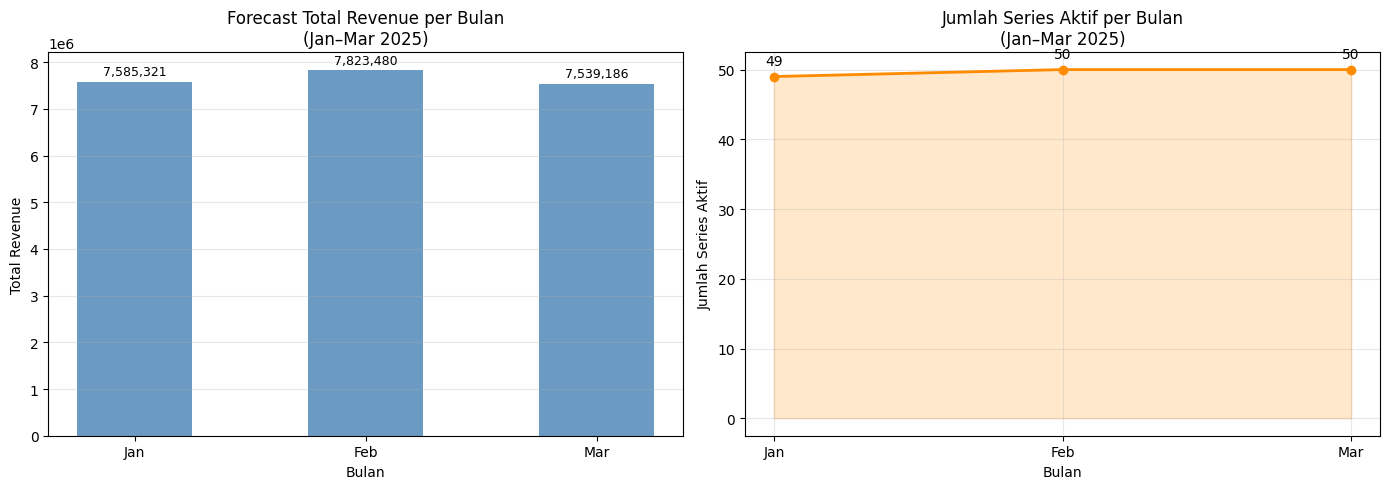


File disimpan:
  • forecast_jan_mar_2025.csv
  • forecast_jan_mar_2025.png


In [68]:
# ═══════════════════════════════════════════════
# STEP 6 — FORECAST MASA DEPAN: JAN–MAR 2025
# ═══════════════════════════════════════════════
import math
import warnings
warnings.filterwarnings('ignore')

# ── 1. Pilih dan re-fit model Stage 2 terbaik pada semua data ──────────
active_mask = monthly['target_active'] == 1
X_all_s2    = monthly.loc[active_mask, FEATURES_STAGE2].values
y_all_s2    = monthly.loc[active_mask, 'target_revenue'].values

try:
    best_name = results_df.loc[results_df['WMAPE(%)'].idxmin(), 'Model']
    use_xgb   = 'XGBoost' in best_name
except NameError:
    use_xgb   = False
    best_name = 'RF + GA (default)'

try:
    if use_xgb:
        reg_final = XGBRegressor(**best_params_xgb, random_state=42, verbosity=0)
    else:
        reg_final = RandomForestRegressor(**best_params_rf, random_state=42, n_jobs=-1)
except NameError:
    reg_final = RandomForestRegressor(random_state=42, n_jobs=-1)
    best_name = 'RF Default (GA params not found)'

reg_final.fit(X_all_s2, y_all_s2)
print(f"Stage 2 model digunakan : {best_name}")
print(f"Train size (aktif)      : {len(y_all_s2)} baris\n")

# ── 2. Rekonstruksi bulan N (terakhir aktual) dari target columns ──────
# monthly sudah di-drop last row per series.
# Baris terakhir monthly = bulan N-1, target = nilai aktual bulan N.
last_rows_df = (monthly.sort_values('period')
                .groupby('Series_ID')
                .last()
                .reset_index())

max_p = monthly['period'].max()
_yr   = max_p // 12
_mo   = max_p % 12
if _mo == 0:
    _mo = 12; _yr -= 1

if _mo == 12:
    last_yr, last_mo = _yr + 1, 1
else:
    last_yr, last_mo = _yr, _mo + 1

print(f"Bulan aktual terakhir  : {last_mo:02d}/{last_yr}")
print(f"Forecast periode       : 01/2025 – 03/2025\n")

STATIC_COLS = [
    'TotalSentMessages', 'TotalDeliveredMessages', 'delivery_rate',
    'profit_margin', 'rateCost', 'unique_OA_count', 'max_OA_revenue',
    'anomaly_count', 'anomaly_revenue_pct',
]

month_n = last_rows_df[['Series_ID']].copy()
month_n['Year']         = last_yr
month_n['Month']        = last_mo
month_n['period']       = last_yr * 12 + last_mo
month_n['is_active']    = last_rows_df['target_active'].fillna(0).astype(int).values
month_n['TotalRevenue'] = last_rows_df['target_revenue'].fillna(0).values
for col in STATIC_COLS:
    month_n[col] = last_rows_df[col].values if col in last_rows_df.columns else 0.0

HISTORY_COLS = ['Series_ID', 'Year', 'Month', 'period', 'is_active', 'TotalRevenue'] + STATIC_COLS
panel_rolling = pd.concat(
    [monthly[HISTORY_COLS], month_n[HISTORY_COLS]],
    ignore_index=True
).sort_values(['Series_ID', 'period'])

# ── 3. Helper: bangun fitur untuk satu bulan forecast ─────────────────
def build_features_for_month(hist_df, static_last, year, month):
    rev = hist_df['TotalRevenue'].values.astype(float)
    act = hist_df['is_active'].values.astype(float)
    n   = len(rev)

    def lag(arr, k):    return float(arr[-k]) if n >= k else 0.0
    def rmean(arr, w):  return float(np.mean(arr[-w:])) if n >= w else (float(np.mean(arr)) if n > 0 else 0.0)
    def rstd(arr, w):   return float(np.std(arr[-w:], ddof=0)) if n >= w else 0.0

    streak = 0
    for v in reversed(act):
        if v == 1: streak += 1
        else: break

    msa = 0
    for v in reversed(act):
        if v == 1: break
        msa += 1

    return {
        'active_lag1': lag(act,1), 'active_lag2': lag(act,2), 'active_lag3': lag(act,3),
        'active_streak': float(streak), 'months_since_active': float(msa),
        'pct_active_3m': rmean(act,3), 'pct_active_6m': rmean(act,6),
        'rev_lag1': lag(rev,1), 'rev_lag2': lag(rev,2), 'rev_lag3': lag(rev,3),
        'rolling_mean_3': rmean(rev,3), 'rolling_mean_6': rmean(rev,6),
        'rolling_std_3':  rstd(rev,3),  'rolling_std_6':  rstd(rev,6),
        'TotalSentMessages':      float(static_last.get('TotalSentMessages', 0)),
        'TotalDeliveredMessages': float(static_last.get('TotalDeliveredMessages', 0)),
        'delivery_rate':          float(static_last.get('delivery_rate', 0)),
        'profit_margin':          float(static_last.get('profit_margin', 0)),
        'rateCost':               float(static_last.get('rateCost', 0)),
        'unique_OA_count':        float(static_last.get('unique_OA_count', 0)),
        'max_OA_revenue':         float(static_last.get('max_OA_revenue', 0)),
        'anomaly_count':          float(static_last.get('anomaly_count', 0)),
        'anomaly_revenue_pct':    float(static_last.get('anomaly_revenue_pct', 0)),
        'month_sin': math.sin(2 * math.pi * month / 12),
        'month_cos': math.cos(2 * math.pi * month / 12),
    }

# ── 4. Forecast iteratif: Jan, Feb, Mar 2025 ──────────────────────────
FORECAST_MONTHS = [(2025, 1), (2025, 2), (2025, 3)]
MONTH_NAME      = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

all_series_ids = monthly['Series_ID'].unique()
forecast_rows  = []

for (yr, mo) in FORECAST_MONTHS:
    feat_list    = []
    series_order = []

    static_last_map = (panel_rolling.groupby('Series_ID')[STATIC_COLS]
                       .last().to_dict('index'))

    for sid in all_series_ids:
        hist    = panel_rolling[panel_rolling['Series_ID'] == sid].sort_values('period')
        statics = static_last_map.get(sid, {c: 0.0 for c in STATIC_COLS})
        feat_list.append(build_features_for_month(hist, statics, yr, mo))
        series_order.append(sid)

    feat_df     = pd.DataFrame(feat_list)
    X_s1        = feat_df[FEATURES_STAGE1].values
    pred_active = clf.predict(X_s1)
    pred_prob   = clf.predict_proba(X_s1)[:, 1]

    pred_revenue = np.zeros(len(series_order))
    active_idx   = np.where(pred_active == 1)[0]
    if len(active_idx) > 0:
        X_s2_fut = feat_df.iloc[active_idx][FEATURES_STAGE2].values
        pred_revenue[active_idx] = np.maximum(0, reg_final.predict(X_s2_fut))

    for i, sid in enumerate(series_order):
        forecast_rows.append({
            'Series_ID':    sid,
            'Year':         yr,
            'Month':        mo,
            'Month_Name':   MONTH_NAME[mo],
            'Pred_Active':  int(pred_active[i]),
            'Prob_Active':  round(float(pred_prob[i]), 4),
            'Pred_Revenue': round(float(pred_revenue[i]), 2),
        })

    # Update rolling panel untuk bulan berikutnya
    new_rows = pd.DataFrame([{
        'Series_ID':    sid,
        'Year':         yr,
        'Month':        mo,
        'period':       yr * 12 + mo,
        'is_active':    int(pred_active[i]),
        'TotalRevenue': float(pred_revenue[i]),
        **{c: static_last_map.get(sid, {}).get(c, 0.0) for c in STATIC_COLS},
    } for i, sid in enumerate(series_order)])
    panel_rolling = pd.concat([panel_rolling, new_rows], ignore_index=True)

    n_active  = int(pred_active.sum())
    total_rev = float(pred_revenue.sum())
    print(f"  {MONTH_NAME[mo]} {yr}  →  Aktif: {n_active:>4} series  |  "
          f"Total Revenue: {total_rev:>16,.2f}")

# ── 5. Ringkasan & visualisasi ─────────────────────────────────────────
forecast_df = pd.DataFrame(forecast_rows)

print("\n" + "═"*65)
print("RINGKASAN FORECAST JAN–MAR 2025")
print("═"*65)

summary = (forecast_df.groupby(['Year','Month','Month_Name'])
           .agg(
               N_Active      = ('Pred_Active', 'sum'),
               Total_Revenue = ('Pred_Revenue', 'sum'),
               N_Total       = ('Series_ID', 'count'),
           )
           .reset_index())
summary['Active_Rate_pct']    = (summary['N_Active'] / summary['N_Total'] * 100).round(1)
summary['Avg_Rev_per_Active'] = np.where(
    summary['N_Active'] > 0,
    (summary['Total_Revenue'] / summary['N_Active']).round(2),
    0
)

print(summary[['Month_Name','N_Active','N_Total','Active_Rate_pct',
               'Total_Revenue','Avg_Rev_per_Active']].to_string(index=False))
print(f"\nTotal Revenue Kumulatif  : {forecast_df['Pred_Revenue'].sum():>15,.2f}")
print(f"Rata-rata aktif/bulan    : {summary['N_Active'].mean():>15.1f} series")

# Visualisasi
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
month_labels  = summary['Month_Name'].tolist()
rev_values    = summary['Total_Revenue'].tolist()
active_values = summary['N_Active'].tolist()
x_pos = list(range(len(month_labels)))

# Plot 1: Total Revenue
ax1 = axes[0]
bars = ax1.bar(x_pos, rev_values, color='steelblue', alpha=0.8, width=0.5)
ax1.set_xticks(x_pos); ax1.set_xticklabels(month_labels)
ax1.set_title('Forecast Total Revenue per Bulan\n(Jan–Mar 2025)')
ax1.set_ylabel('Total Revenue'); ax1.set_xlabel('Bulan')
for bar, val in zip(bars, rev_values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Jumlah series aktif
ax2 = axes[1]
ax2.plot(x_pos, active_values, marker='o', linewidth=2, color='darkorange')
ax2.fill_between(x_pos, active_values, alpha=0.2, color='darkorange')
ax2.set_xticks(x_pos); ax2.set_xticklabels(month_labels)
ax2.set_title('Jumlah Series Aktif per Bulan\n(Jan–Mar 2025)')
ax2.set_ylabel('Jumlah Series Aktif'); ax2.set_xlabel('Bulan')
for i, v in enumerate(active_values):
    ax2.annotate(str(int(v)), (i, v), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_jan_mar_2025.png', dpi=150, bbox_inches='tight')
plt.show()

# Simpan ke CSV
forecast_df.to_csv('forecast_jan_mar_2025.csv', index=False)
print("\nFile disimpan:")
print("  • forecast_jan_mar_2025.csv")
print("  • forecast_jan_mar_2025.png")


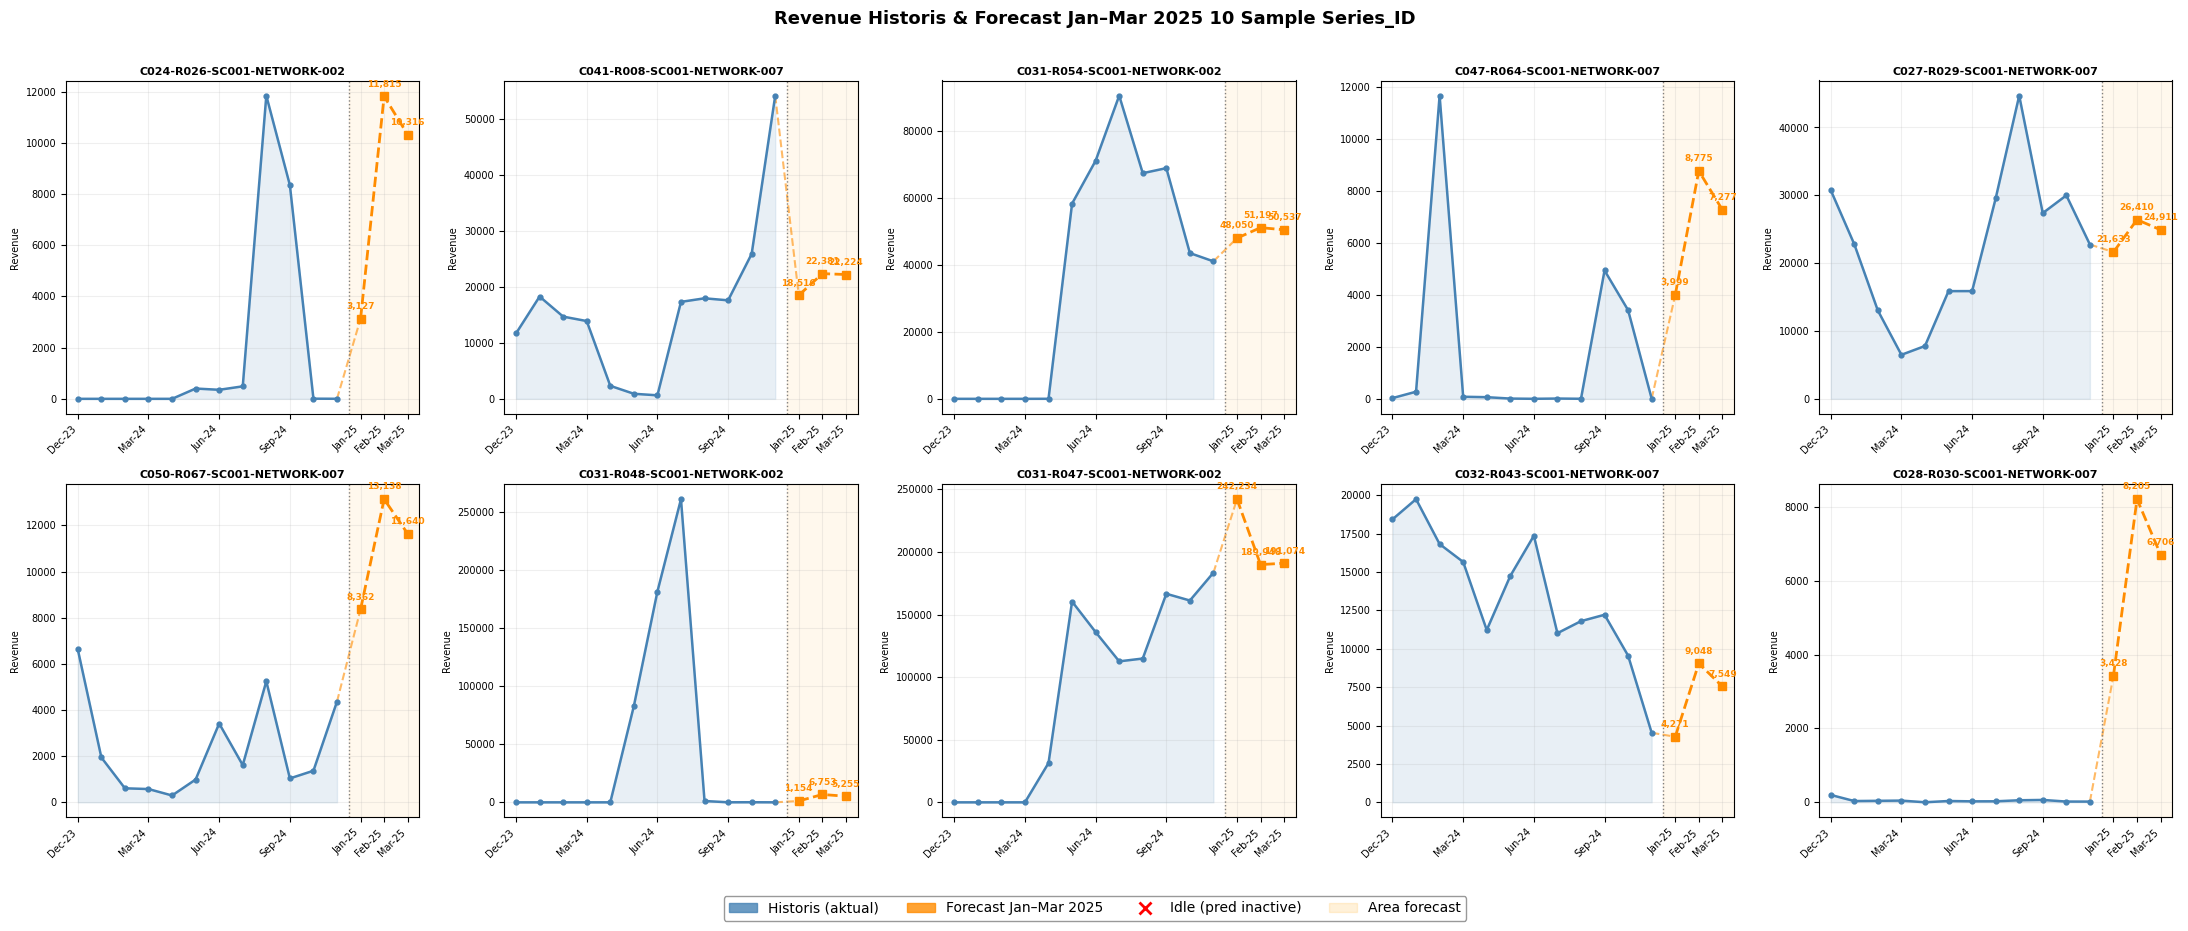

Plot disimpan: forecast_sample_series.png
Sample series: [np.str_('CLIENT_024_ROUTE_026_SUPPLIERCONNECTION_001_NETWORK_002'), np.str_('CLIENT_041_ROUTE_008_SUPPLIERCONNECTION_001_NETWORK_007'), np.str_('CLIENT_031_ROUTE_054_SUPPLIERCONNECTION_001_NETWORK_002'), np.str_('CLIENT_047_ROUTE_064_SUPPLIERCONNECTION_001_NETWORK_007'), np.str_('CLIENT_027_ROUTE_029_SUPPLIERCONNECTION_001_NETWORK_007'), np.str_('CLIENT_050_ROUTE_067_SUPPLIERCONNECTION_001_NETWORK_007'), np.str_('CLIENT_031_ROUTE_048_SUPPLIERCONNECTION_001_NETWORK_002'), np.str_('CLIENT_031_ROUTE_047_SUPPLIERCONNECTION_001_NETWORK_002'), np.str_('CLIENT_032_ROUTE_043_SUPPLIERCONNECTION_001_NETWORK_007'), np.str_('CLIENT_028_ROUTE_030_SUPPLIERCONNECTION_001_NETWORK_007')]


In [69]:
# ═══════════════════════════════════════════════
# STEP 6b — PLOT 10 SAMPLE SERIES_ID: HISTORIS + FORECAST
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np

MONTH_SH = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
            7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

# ── Pilih 10 sample series ─────────────────────────────────────────────
# Prioritaskan series yang aktif di minimal 1 bulan forecast
active_in_fc = (forecast_df.groupby('Series_ID')['Pred_Active']
                .sum().loc[lambda s: s > 0].index.tolist())
all_sids = monthly['Series_ID'].unique().tolist()

np.random.seed(42)
if len(active_in_fc) >= 10:
    sample_ids = list(np.random.choice(active_in_fc, 10, replace=False))
else:
    others = [s for s in all_sids if s not in active_in_fc]
    extra  = list(np.random.choice(others, min(10 - len(active_in_fc), len(others)), replace=False))
    sample_ids = active_in_fc + extra

# ── Setup figure ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

N_HIST_SHOW = 12   # tampilkan 12 bulan historis terakhir

for ax, sid in zip(axes, sample_ids):
    # ─ Data historis (12 bulan terakhir)
    hist = (monthly[monthly['Series_ID'] == sid]
            .sort_values('period')
            .tail(N_HIST_SHOW))

    hist_rev    = hist['TotalRevenue'].values.astype(float)
    hist_labels = [f"{MONTH_SH[int(r.Month)]}-{int(r.Year)%100:02d}"
                   for r in hist.itertuples()]

    # ─ Data forecast (Jan–Mar 2025)
    fc = (forecast_df[forecast_df['Series_ID'] == sid]
          .sort_values('Month'))
    fc_rev    = fc['Pred_Revenue'].values.astype(float)
    fc_active = fc['Pred_Active'].values.astype(int)
    fc_labels = [f"{MONTH_SH[int(r.Month)]}-25" for r in fc.itertuples()]

    n_h = len(hist_labels)
    n_f = len(fc_labels)
    x_h = np.arange(n_h)
    x_f = np.arange(n_h, n_h + n_f)

    # ─ Plot historis (solid, biru)
    ax.plot(x_h, hist_rev, color='steelblue', linewidth=1.8,
            marker='o', markersize=3.5, zorder=3)
    ax.fill_between(x_h, hist_rev, alpha=0.12, color='steelblue')

    # ─ Koneksi historis → forecast
    if n_h > 0 and n_f > 0:
        ax.plot([x_h[-1], x_f[0]], [hist_rev[-1], fc_rev[0]],
                color='darkorange', linewidth=1.5, linestyle='--', alpha=0.6, zorder=2)

    # ─ Plot forecast (dashed, oranye)
    ax.plot(x_f, fc_rev, color='darkorange', linewidth=2,
            marker='s', markersize=6, linestyle='--', zorder=4)

    # ─ Tandai bulan idle di forecast dengan X merah
    for xj, rv, act in zip(x_f, fc_rev, fc_active):
        if act == 0:
            ax.scatter([xj], [rv], marker='x', color='red',
                       s=80, linewidths=2, zorder=5)

    # ─ Area forecast (shading)
    if n_f > 0:
        ax.axvspan(n_h - 0.5, n_h + n_f - 0.5, alpha=0.07, color='orange', zorder=1)
        ax.axvline(x=n_h - 0.5, color='gray', linestyle=':', linewidth=1, zorder=2)

    # ─ Anotasi nilai forecast di atas marker
    for xj, rv, act in zip(x_f, fc_rev, fc_active):
        if rv > 0:
            ax.annotate(f'{rv:,.0f}', (xj, rv),
                        textcoords='offset points', xytext=(0, 7),
                        ha='center', fontsize=6.5, color='darkorange', fontweight='bold')

    # ─ X-ticks: setiap 3 bulan historis + semua forecast
    tick_pos    = list(range(0, n_h, 3)) + list(x_f)
    all_labels  = hist_labels + fc_labels
    tick_labels = [all_labels[i] for i in tick_pos]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)

    # ─ Title: singkat agar muat
    short = (sid.replace('CLIENT_','C').replace('ROUTE_','R')
               .replace('SUPPLIERCONNECTION_','SC').replace('_','-'))
    if len(short) > 28:
        short = short[:28] + '…'
    ax.set_title(short, fontsize=8, fontweight='bold', pad=4)
    ax.set_ylabel('Revenue', fontsize=7)
    ax.grid(alpha=0.2)
    ax.set_xlim(-0.5, n_h + n_f - 0.5)

# ── Legend global ──────────────────────────────────────────────────────
h1 = mpatches.Patch(color='steelblue',  alpha=0.8, label='Historis (aktual)')
h2 = mpatches.Patch(color='darkorange', alpha=0.8, label='Forecast Jan–Mar 2025')
h3 = mlines.Line2D([], [], color='red', marker='x', linestyle='None',
                   markersize=8, markeredgewidth=2, label='Idle (pred inactive)')
h4 = mpatches.Patch(color='orange', alpha=0.15, label='Area forecast')

fig.legend(handles=[h1, h2, h3, h4], loc='lower center',
           ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01),
           frameon=True, edgecolor='gray')

fig.suptitle(
    'Revenue Historis & Forecast Jan–Mar 2025 10 Sample Series_ID',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('forecast_sample_series.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot disimpan: forecast_sample_series.png")
print(f"Sample series: {sample_ids}")
